In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import time

In [2]:
class graphWithComplement:

    def __init__(self, n, p=None):
        self.n = n
        self.half_of_all_edges = n*(n-1)//4
        if p is None:
            self.graph = nx.empty_graph(n)
            self.complement = nx.complete_graph(n)
        else:
            self.graph = nx.fast_gnp_random_graph(n, p)
            self.complement = nx.complement(self.graph)

    def add_edge(self, u, v):
        self.graph.add_edge(u, v)
        self.complement.remove_edge(u, v)

    def remove_edge(self, u, v):
        self.graph.remove_edge(u, v)
        self.complement.add_edge(u, v)

    def has_edge(self, u, v):
        return self.graph.has_edge(u, v)
    
    def number_of_common_neighbors(self, u, v, m=None):
        if m is None or m<self.half_of_all_edges:
            return len(nx.common_neighbors(self.graph, u, v))
        else:
            return self.n - 2 - len((self.complement.adj[u].keys() | self.complement.adj[v].keys()) - {u,v})

In [3]:
import networkx as nx
import itertools
from collections import Counter

def edge_triangle_distribution(n):
    nc2 = n * (n - 1) // 2
    all_edges = list(itertools.combinations(range(n), 2))
    
    distribution = Counter()

    for i in range(2**nc2):
        G = nx.Graph()
        G.add_nodes_from(range(n))
        
        edges_to_add = [all_edges[j] for j in range(nc2) if (i >> j) & 1]
        G.add_edges_from(edges_to_add)
        
        m = G.number_of_edges()
        t = sum(nx.triangles(G).values()) // 3
        
        distribution[(m, t)] += 1

        if i % 100000 == 0 and i > 0:
            print(f"Processed {i} graphs...")

    return distribution

n = 7
dist = edge_triangle_distribution(n)

print(f"Joint distribution for n={n}:")
total_graphs = 0
for (m, t), count in sorted(dist.items()):
    print(f"Edges: {m}, Triangles: {t} -> Count: {count}")
    total_graphs += count
print(total_graphs)


Processed 100000 graphs...
Processed 200000 graphs...
Processed 300000 graphs...
Processed 400000 graphs...
Processed 500000 graphs...
Processed 600000 graphs...
Processed 700000 graphs...
Processed 800000 graphs...
Processed 900000 graphs...
Processed 1000000 graphs...
Processed 1100000 graphs...
Processed 1200000 graphs...
Processed 1300000 graphs...
Processed 1400000 graphs...
Processed 1500000 graphs...
Processed 1600000 graphs...
Processed 1700000 graphs...
Processed 1800000 graphs...
Processed 1900000 graphs...
Processed 2000000 graphs...
Joint distribution for n=7:
Edges: 0, Triangles: 0 -> Count: 1
Edges: 1, Triangles: 0 -> Count: 21
Edges: 2, Triangles: 0 -> Count: 210
Edges: 3, Triangles: 0 -> Count: 1295
Edges: 3, Triangles: 1 -> Count: 35
Edges: 4, Triangles: 0 -> Count: 5355
Edges: 4, Triangles: 1 -> Count: 630
Edges: 5, Triangles: 0 -> Count: 15204
Edges: 5, Triangles: 1 -> Count: 4935
Edges: 5, Triangles: 2 -> Count: 210
Edges: 6, Triangles: 0 -> Count: 29344
Edges: 6, T

In [4]:
import itertools
from collections import Counter

def count_edge_triangle_fast(n):
    # 1. Pre-calculate all possible edges
    nodes = list(range(n))
    all_edges = list(itertools.combinations(nodes, 2))
    nc2 = len(all_edges)
    
    # 2. Map edge-tuples to their index for fast lookup
    edge_to_idx = {edge: i for i, edge in enumerate(all_edges)}
    
    # 3. Pre-calculate which edge-index triplets form a triangle
    # A triangle exists if edges (u,v), (v,w), and (u,w) are all present
    triangle_indices = []
    for triplet in itertools.combinations(nodes, 3):
        u, v, w = sorted(triplet)
        # Find the indices of the three edges forming this triangle
        e1 = edge_to_idx[(u, v)]
        e2 = edge_to_idx[(v, w)]
        e3 = edge_to_idx[(u, w)]
        triangle_indices.append((e1, e2, e3))

    distribution = Counter()
    
    # 4. Brute force iteration
    for i in range(1 << nc2):
        # Count edges: count number of set bits in i
        m = bin(i).count('1')
        
        # Count triangles: check if the bits at the pre-calculated indices are all 1
        t = 0
        for e1, e2, e3 in triangle_indices:
            if (i >> e1) & 1 and (i >> e2) & 1 and (i >> e3) & 1:
                t += 1
        
        distribution[(m, t)] += 1
        
    return distribution

n = 7
fast_dist = count_edge_triangle_fast(n)

print(f"Joint distribution for n={n}:")
total_graphs = 0
for (m, t), count in sorted(fast_dist.items()):
    print(f"Edges: {m}, Triangles: {t} -> Count: {count}")
    total_graphs += count
print(total_graphs)


Joint distribution for n=7:
Edges: 0, Triangles: 0 -> Count: 1
Edges: 1, Triangles: 0 -> Count: 21
Edges: 2, Triangles: 0 -> Count: 210
Edges: 3, Triangles: 0 -> Count: 1295
Edges: 3, Triangles: 1 -> Count: 35
Edges: 4, Triangles: 0 -> Count: 5355
Edges: 4, Triangles: 1 -> Count: 630
Edges: 5, Triangles: 0 -> Count: 15204
Edges: 5, Triangles: 1 -> Count: 4935
Edges: 5, Triangles: 2 -> Count: 210
Edges: 6, Triangles: 0 -> Count: 29344
Edges: 6, Triangles: 1 -> Count: 21350
Edges: 6, Triangles: 2 -> Count: 3535
Edges: 6, Triangles: 4 -> Count: 35
Edges: 7, Triangles: 0 -> Count: 37110
Edges: 7, Triangles: 1 -> Count: 53760
Edges: 7, Triangles: 2 -> Count: 23415
Edges: 7, Triangles: 3 -> Count: 1470
Edges: 7, Triangles: 4 -> Count: 525
Edges: 8, Triangles: 0 -> Count: 28875
Edges: 8, Triangles: 1 -> Count: 76860
Edges: 8, Triangles: 2 -> Count: 74865
Edges: 8, Triangles: 3 -> Count: 18900
Edges: 8, Triangles: 4 -> Count: 3360
Edges: 8, Triangles: 5 -> Count: 630
Edges: 9, Triangles: 0 -> 

In [5]:
print(fast_dist == dist)  # Should be True

True


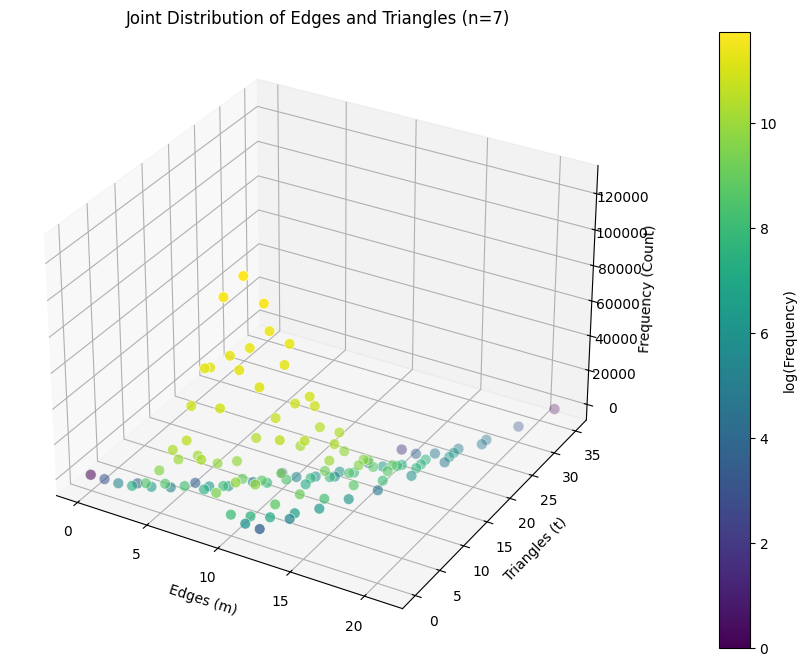

In [6]:
# 3. Quick 3D Plotting
m_vals, t_vals, counts = zip(*[(m, t, c) for (m, t), c in fast_dist.items()])

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Use log scale for color because counts vary exponentially
scatter = ax.scatter(m_vals, t_vals, counts, 
                        c=np.log(counts), cmap='viridis', 
                        s=60, edgecolors='w', linewidth=0.5)

ax.set_xlabel('Edges (m)')
ax.set_ylabel('Triangles (t)')
ax.set_zlabel('Frequency (Count)')
plt.colorbar(scatter, label='log(Frequency)', pad=0.1)

plt.title(f'Joint Distribution of Edges and Triangles (n={n})')
plt.show()

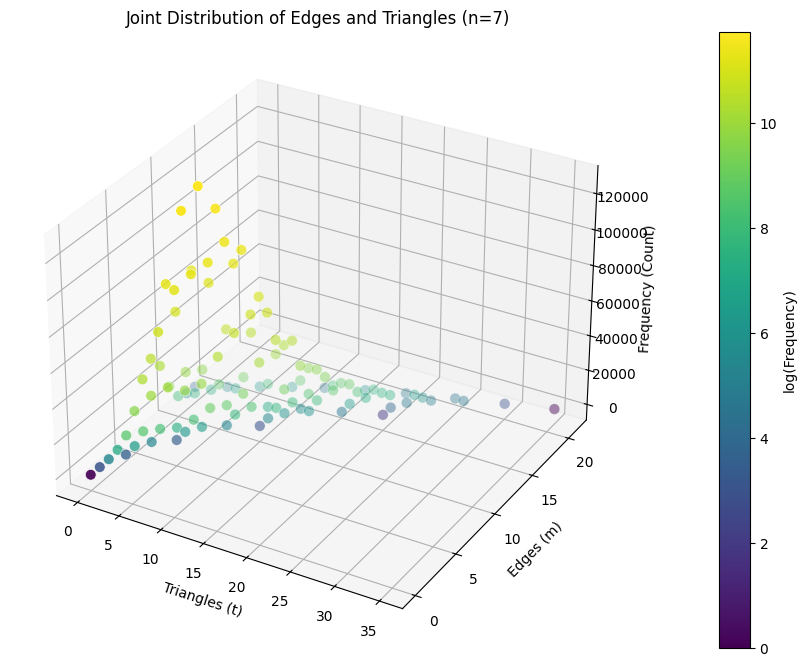

In [7]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Use log scale for color because counts vary exponentially
scatter = ax.scatter(t_vals, m_vals, counts, 
                        c=np.log(counts), cmap='viridis', 
                        s=60, edgecolors='w', linewidth=0.5)

ax.set_ylabel('Edges (m)')
ax.set_xlabel('Triangles (t)')
ax.set_zlabel('Frequency (Count)')
plt.colorbar(scatter, label='log(Frequency)', pad=0.1)

plt.title(f'Joint Distribution of Edges and Triangles (n={n})')
plt.show()

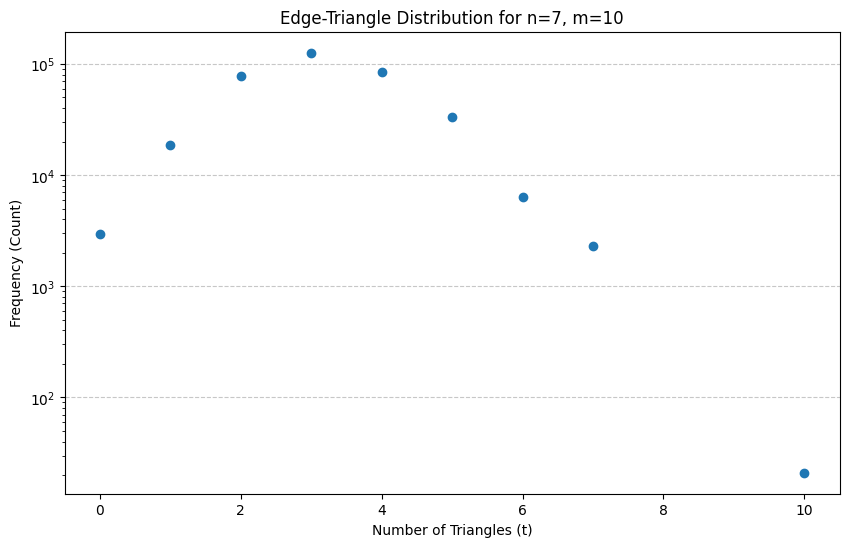

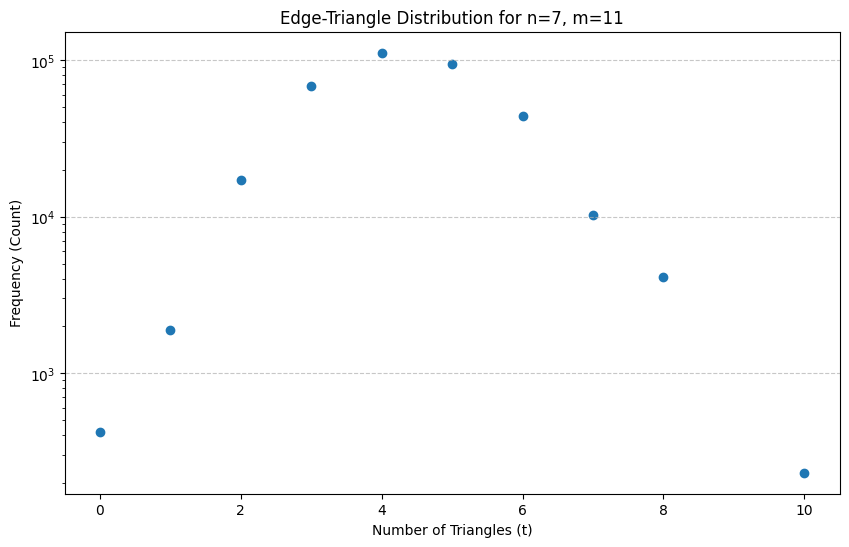

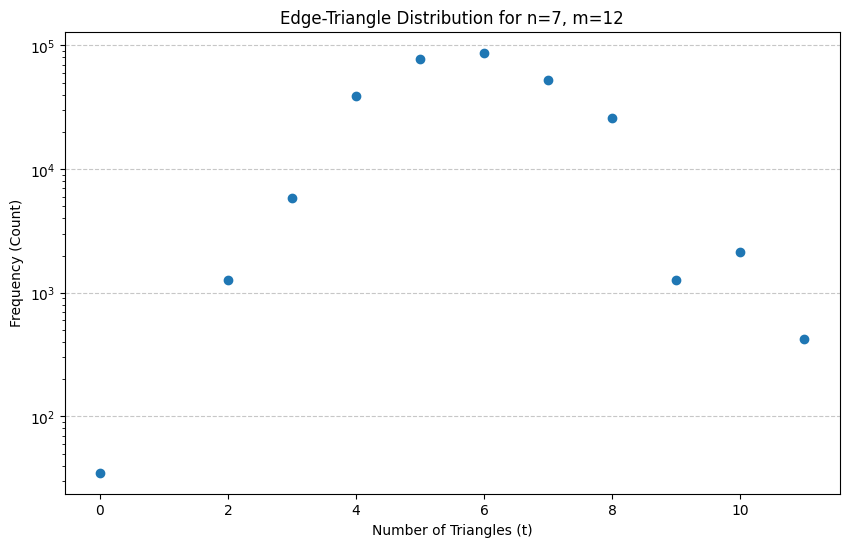

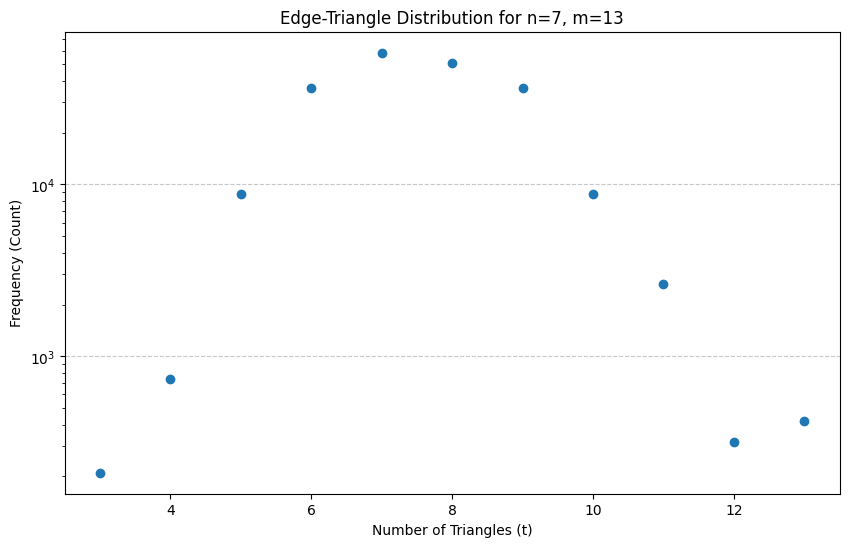

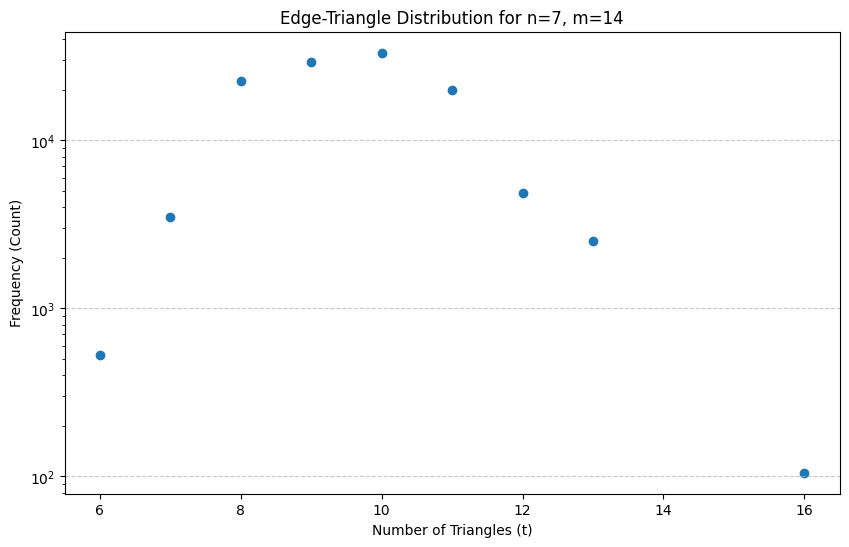

In [8]:
#list of t_vals for fixed m_vals
t_fixed_m = {}
for (m, t), c in fast_dist.items():
    if m not in t_fixed_m:
        t_fixed_m[m] = []
    t_fixed_m[m].append((t, c))

for m in [10, 11, 12, 13, 14]:
    t_vals, counts = zip(*sorted(t_fixed_m[m]))
    plt.figure(figsize=(10, 6))
    plt.scatter(t_vals, counts)
    plt.yscale('log')
    plt.xlabel('Number of Triangles (t)')
    plt.ylabel('Frequency (Count)')
    plt.title(f'Edge-Triangle Distribution for n={n}, m={m}')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


In [9]:
import subprocess
import networkx as nx
import pynauty as nauty
from collections import Counter
import math
import io

def get_exact_distribution_from_geng(n):
    # geng n -q: generates all non-isomorphic graphs silently
    process = subprocess.Popen(
        ['geng', str(n), '-q'], 
        stdout=subprocess.PIPE, 
        text=True
    )
    
    distribution = Counter()
    n_fact = math.factorial(n)
    
    print(f"Streaming and analyzing graphs for n={n}...")
    
    for line in process.stdout:
        g6_str = line.strip()
        if not g6_str: continue
        
        # 1. Get graph invariants
        G = nx.from_graph6_bytes(g6_str.encode())
        m = G.number_of_edges()
        t = sum(nx.triangles(G).values()) // 3
        
        # 2. Calculate Automorphism Group Size using pynauty
        adj_dict = {u: list(v) for u, v in G.adjacency()}
        g_nauty = nauty.Graph(number_of_vertices=n, adjacency_dict=adj_dict)
        res = nauty.autgrp(g_nauty)
        aut_size = int(res[1]) # res[1] is the exact group size
        
        # 3. Apply the weight
        weight = n_fact // aut_size
        distribution[(m, t)] += weight

    process.wait()
    return distribution

n = 10
exact_dist = get_exact_distribution_from_geng(n)
total = 0
print(f"Exact Joint distribution for n={n}:")
for (m, t), count in sorted(exact_dist.items()):
    total += count
    print(f"Edges: {m}, Triangles: {t} -> Count: {count}")
print(total)


Streaming and analyzing graphs for n=10...
Exact Joint distribution for n=10:
Edges: 0, Triangles: 0 -> Count: 1
Edges: 1, Triangles: 0 -> Count: 45
Edges: 2, Triangles: 0 -> Count: 990
Edges: 3, Triangles: 0 -> Count: 14070
Edges: 3, Triangles: 1 -> Count: 120
Edges: 4, Triangles: 0 -> Count: 143955
Edges: 4, Triangles: 1 -> Count: 5040
Edges: 5, Triangles: 0 -> Count: 1119699
Edges: 5, Triangles: 1 -> Count: 100800
Edges: 5, Triangles: 2 -> Count: 1260
Edges: 6, Triangles: 0 -> Count: 6823110
Edges: 6, Triangles: 1 -> Count: 1266720
Edges: 6, Triangles: 2 -> Count: 55020
Edges: 6, Triangles: 4 -> Count: 210
Edges: 7, Triangles: 0 -> Count: 33117930
Edges: 7, Triangles: 1 -> Count: 11125800
Edges: 7, Triangles: 2 -> Count: 1110060
Edges: 7, Triangles: 3 -> Count: 17640
Edges: 7, Triangles: 4 -> Count: 8190
Edges: 8, Triangles: 0 -> Count: 129059865
Edges: 8, Triangles: 1 -> Count: 71951040
Edges: 8, Triangles: 2 -> Count: 13664700
Edges: 8, Triangles: 3 -> Count: 718200
Edges: 8, Tria

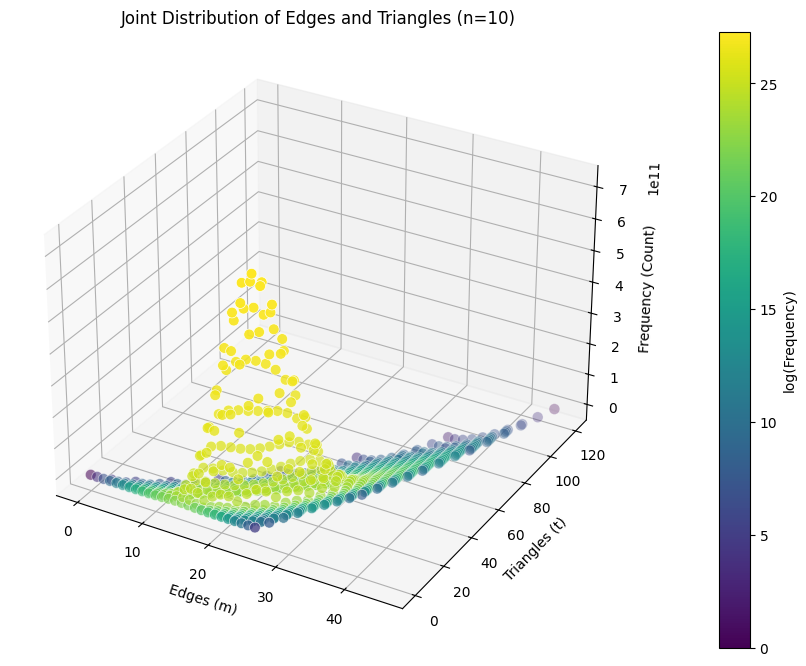

In [10]:
# 3. Quick 3D Plotting
m_vals, t_vals, counts = zip(*[(m, t, c) for (m, t), c in exact_dist.items()])

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Use log scale for color because counts vary exponentially
scatter = ax.scatter(m_vals, t_vals, counts, 
                        c=np.log(counts), cmap='viridis', 
                        s=60, edgecolors='w', linewidth=0.5)

ax.set_xlabel('Edges (m)')
ax.set_ylabel('Triangles (t)')
ax.set_zlabel('Frequency (Count)')
plt.colorbar(scatter, label='log(Frequency)', pad=0.1)

plt.title(f'Joint Distribution of Edges and Triangles (n={n})')
plt.show()

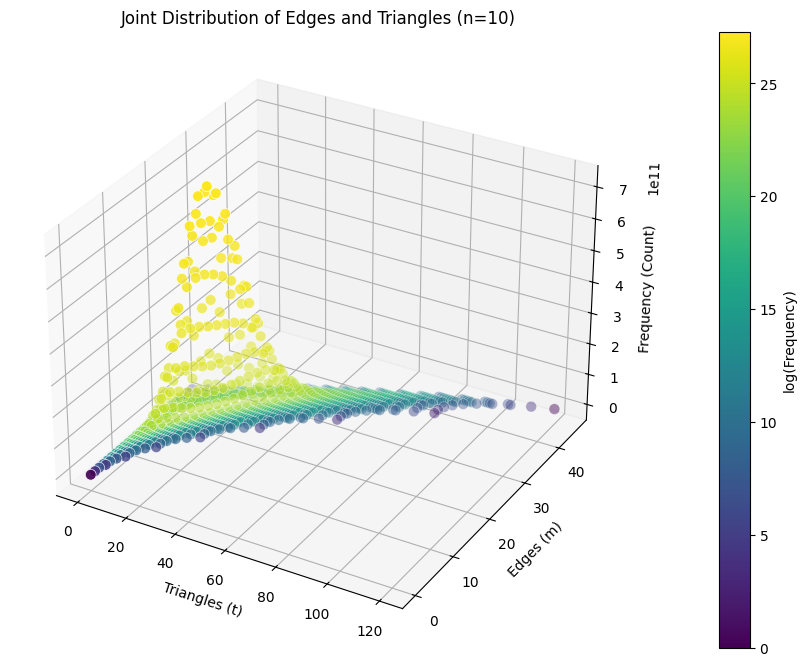

In [11]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Use log scale for color because counts vary exponentially
scatter = ax.scatter(t_vals, m_vals, counts, 
                        c=np.log(counts), cmap='viridis', 
                        s=60, edgecolors='w', linewidth=0.5)

ax.set_ylabel('Edges (m)')
ax.set_xlabel('Triangles (t)')
ax.set_zlabel('Frequency (Count)')
plt.colorbar(scatter, label='log(Frequency)', pad=0.1)

plt.title(f'Joint Distribution of Edges and Triangles (n={n})')
plt.show()

In [17]:
import pandas as pd

# 1. Convert the dictionary items into a list of records
data = [
    {'Edges': m, 'Triangles': t, 'Count': count} 
    for (m, t), count in exact_dist.items()
]

# 2. Create the DataFrame
df = pd.DataFrame(data)

# 3. (Optional) Sort by Edges and Triangles for cleaner reading
df = df.sort_values(by=['Edges', 'Triangles'])

# 5. Save to CSV
filename = f'joint_distribution_n{n}.csv'
df.to_csv(filename, index=False)

print(f"DataFrame saved to {filename}")
print(df.head())

DataFrame saved to joint_distribution_n10.csv
    Edges  Triangles  Count
0       0          0      1
1       1          0     45
2       2          0    990
3       3          0  14070
10      3          1    120


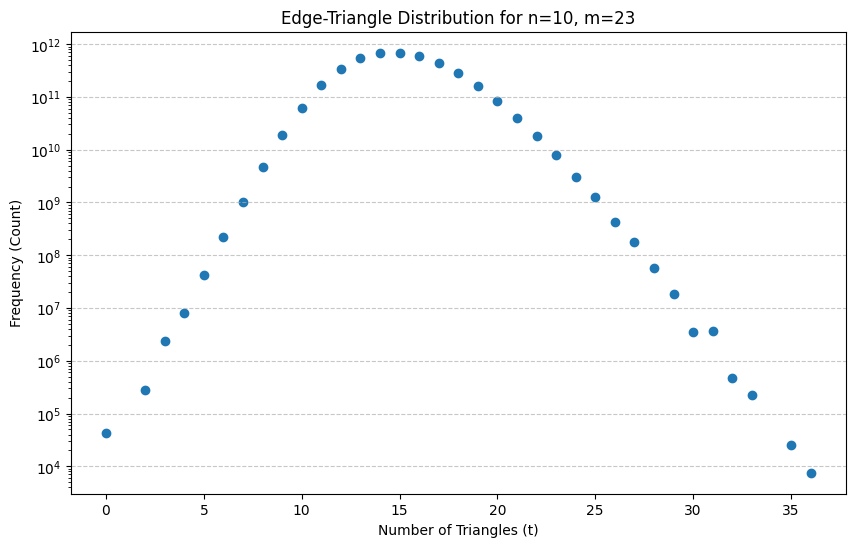

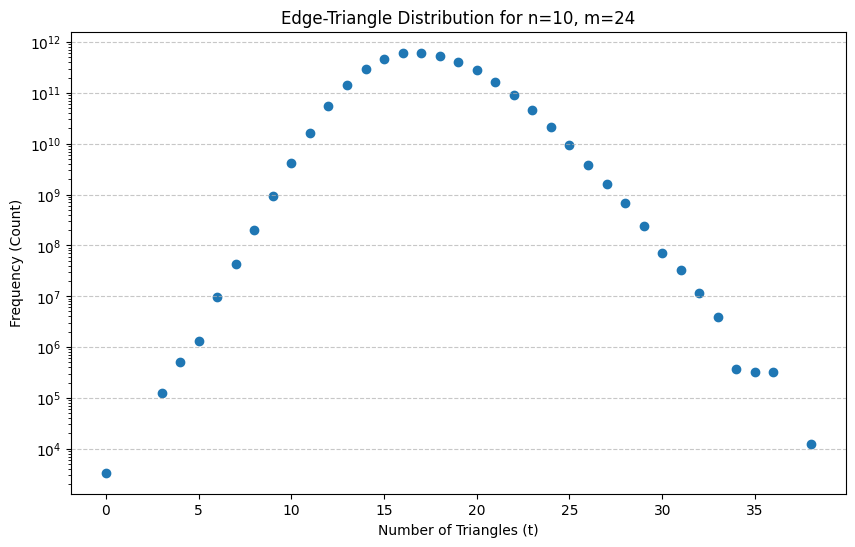

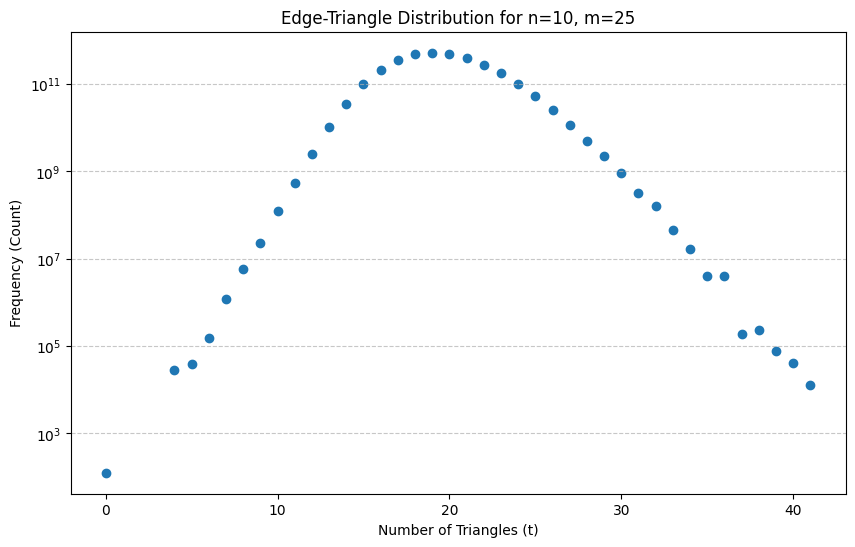

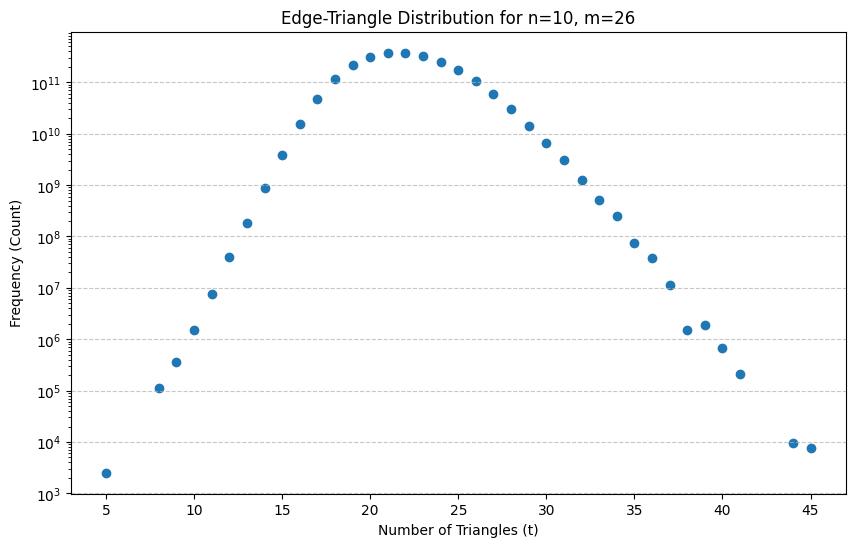

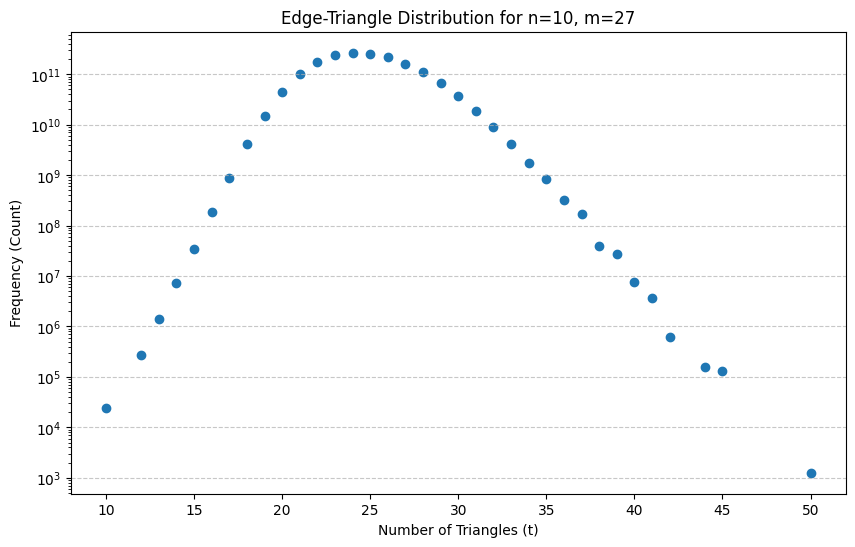

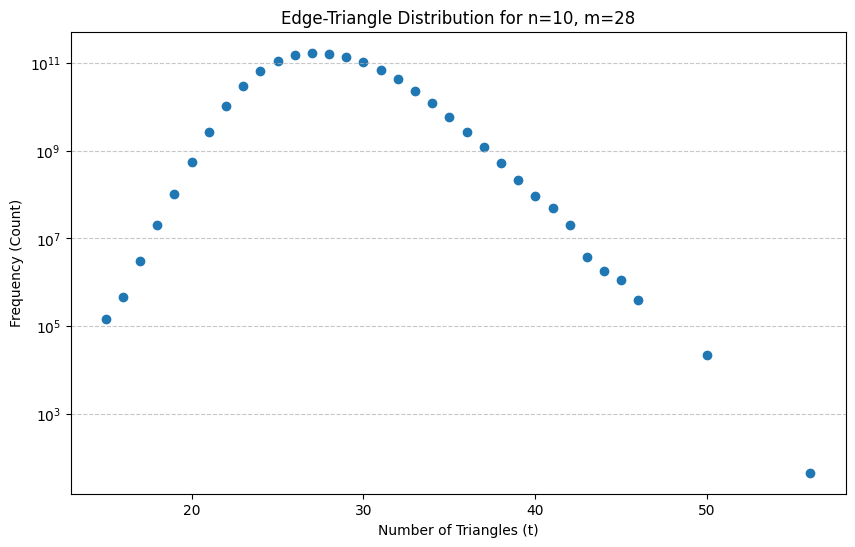

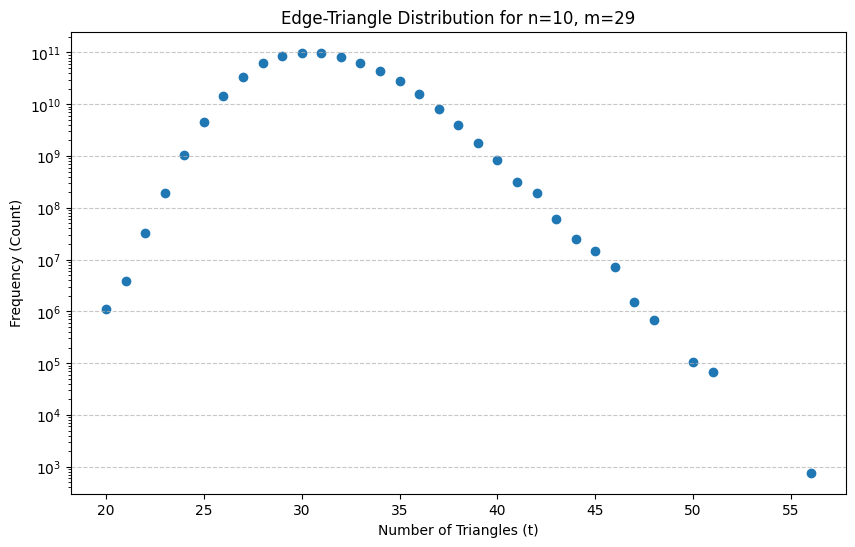

In [12]:
#list of t_vals for fixed m_vals
t_fixed_m = {}
for (m, t), c in exact_dist.items():
    if m not in t_fixed_m:
        t_fixed_m[m] = []
    t_fixed_m[m].append((t, c))

for m in range(23, 30, 1):
    t_vals, counts = zip(*sorted(t_fixed_m[m]))
    plt.figure(figsize=(10, 6))
    plt.scatter(t_vals, counts)
    plt.yscale('log')
    plt.xlabel('Number of Triangles (t)')
    plt.ylabel('Frequency (Count)')
    plt.title(f'Edge-Triangle Distribution for n={n}, m={m}')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


In [4]:
import mpmath
mpmath.dps = 50
mpmath.mp.dps = 50
def find_parameters(n, m_star, t_star, exact_dist=exact_dist):
    def equations(alpha, beta, gamma):
        total_prob = 0
        prev_total_prob = -1
        expected_edges = 0
        expected_triangles = 0
        prev_expected_edges = -1
        #print(f"Trying alpha={alpha}, beta={beta}, gamma={gamma}")
        for (m, t), count in sorted(exact_dist.items()):
            square_term = alpha - beta * m - gamma * t
            prob_m_edges = count * mpmath.exp(-square_term * square_term)
            total_prob += prob_m_edges
            expected_edges += m * prob_m_edges
            expected_triangles += t * prob_m_edges
            """
            if m>m_star and total_prob == prev_total_prob and expected_edges == prev_expected_edges:
                break
            prev_total_prob = total_prob
            prev_expected_edges = expected_edges"""
        return [total_prob - 1, expected_edges - m_star, expected_triangles - t_star]
    beta_start = 0.1
    gamma_start = 0.1
    alpha_start = 0.1
    roots = mpmath.findroot(equations, [alpha_start, beta_start, gamma_start],tol=1e-4, maxsteps = 1000)
    return roots

In [3]:
exact_dist = {}


In [5]:
import matplotlib.pyplot as plt
def plot_distribution(alpha, beta, gamma, exact_dist=exact_dist, m_star=None, t_star=None):
    m_vals, t_vals, raw_probs = zip(*[(m, t, c*mpmath.exp(-(alpha - beta * m - gamma * t)**2)) for (m, t), c in exact_dist.items()])

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    probs = [float(p) for p in raw_probs]
    scatter = ax.scatter(m_vals, t_vals, probs, 
                            c=probs, cmap='viridis', 
                            s=60, edgecolors='w', linewidth=0.5)

    ax.set_xlabel('Edges (m)')
    ax.set_ylabel('Triangles (t)')
    ax.set_zlabel('Probability')
    plt.colorbar(scatter, label='Probability', pad=0.1)
    if m_star is not None and t_star is not None:
        plt.title(f'Joint Distribution of Edges and Triangles (n={n}, m* = {m_star}, t* = {t_star})')
        #add a vertical line with increasing z at m_star, t_star
        ax.plot([m_star]*2, [t_star]*2, [0, 1.1*max(probs)], color='red', label='m* and t*')
        plt.legend()
    plt.show()


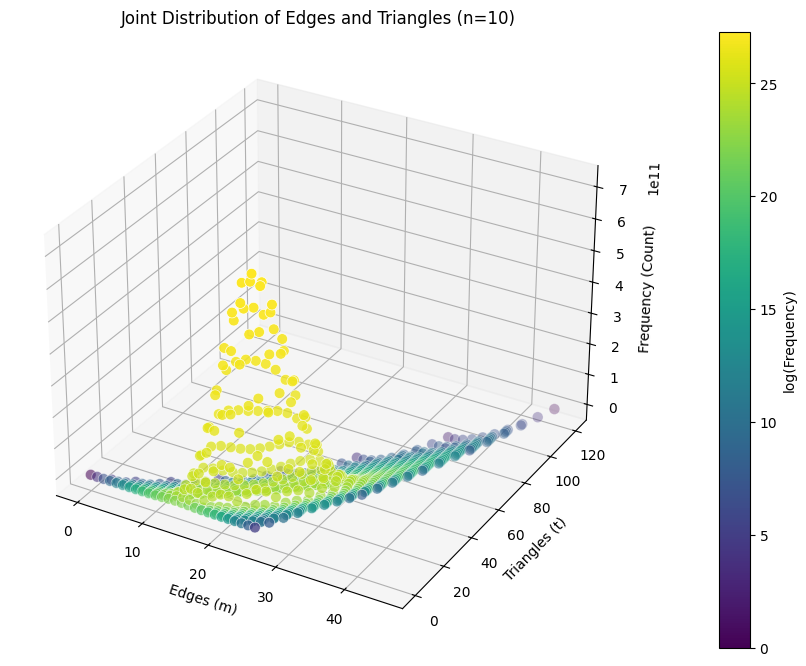

In [15]:
# 3. Quick 3D Plotting
m_vals, t_vals, counts = zip(*[(m, t, c) for (m, t), c in exact_dist.items()])

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Use log scale for color because counts vary exponentially
scatter = ax.scatter(m_vals, t_vals, counts, 
                        c=np.log(counts), cmap='viridis', 
                        s=60, edgecolors='w', linewidth=0.5)

ax.set_xlabel('Edges (m)')
ax.set_ylabel('Triangles (t)')
ax.set_zlabel('Frequency (Count)')
plt.colorbar(scatter, label='log(Frequency)', pad=0.1)

plt.title(f'Joint Distribution of Edges and Triangles (n={n})')
plt.show()

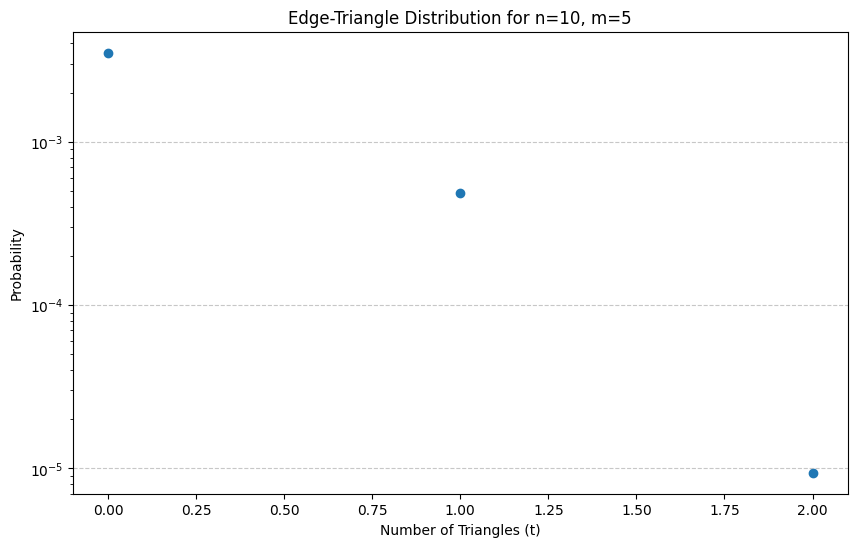

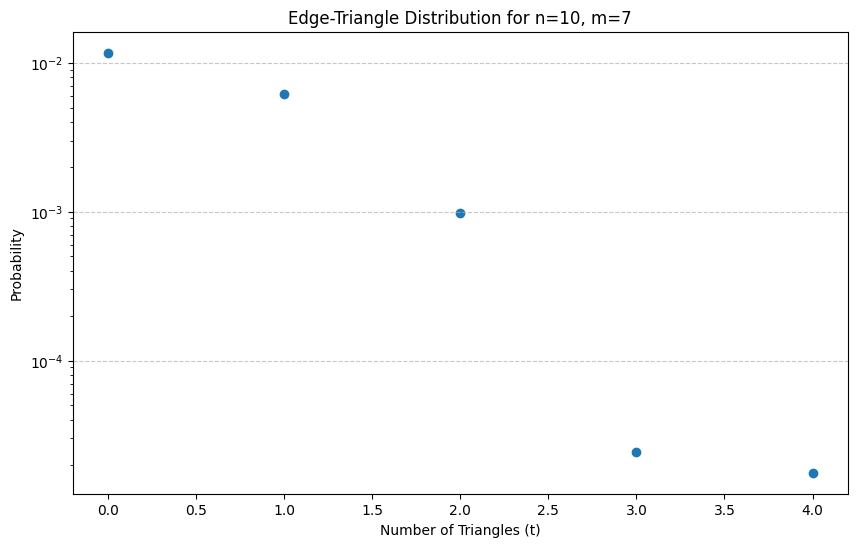

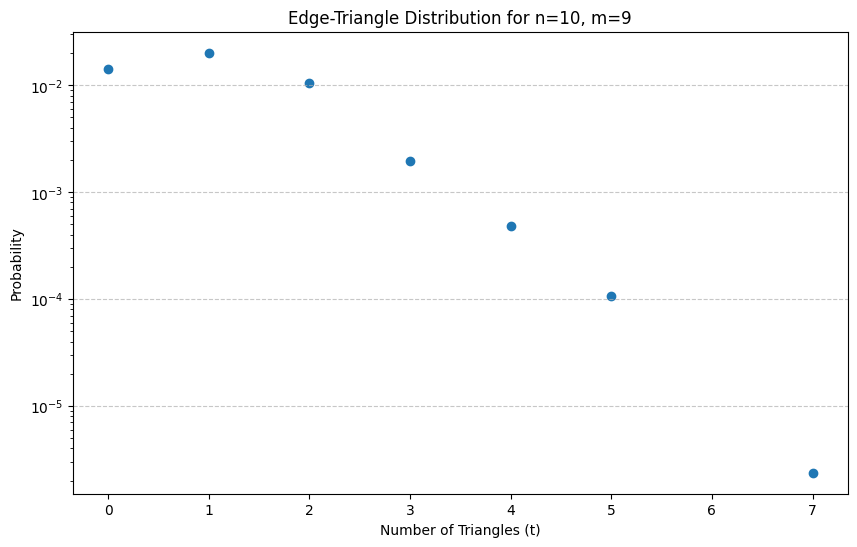

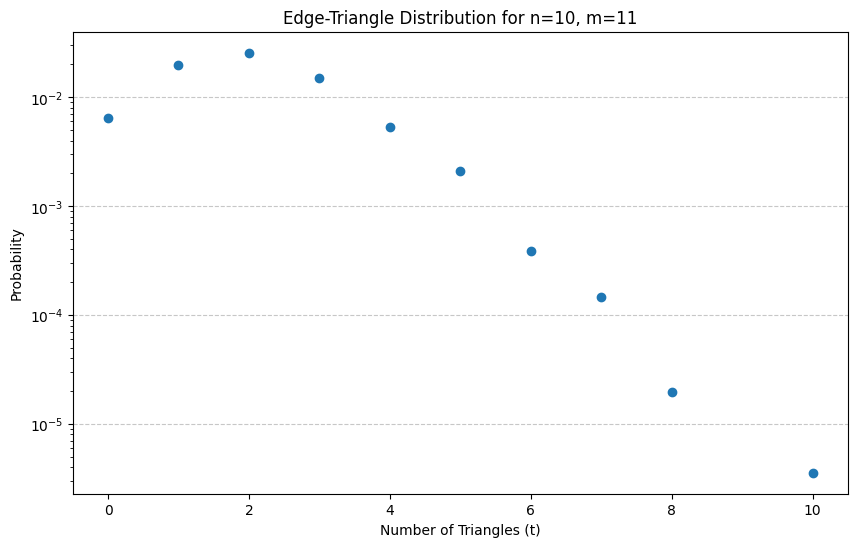

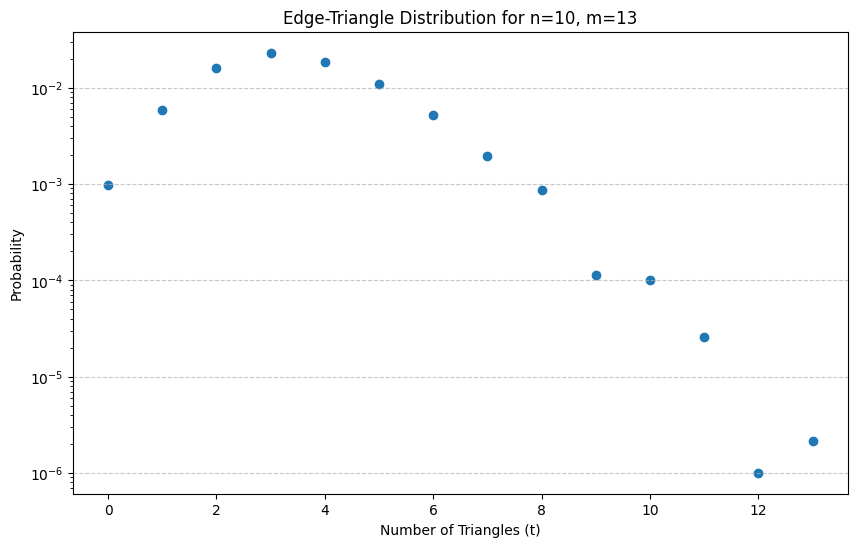

In [16]:
#list of t_vals for fixed m_vals
t_fixed_m = {}
for (m, t), c in exact_dist.items():
    if m not in t_fixed_m:
        t_fixed_m[m] = []
    t_fixed_m[m].append((t, c))

for m in range(5, 15, 2):
    t_vals, counts = zip(*sorted(t_fixed_m[m]))
    probs = [c*mpmath.exp(-(roots[0] - roots[1] * m - roots[2] * t)**2) for t, c in zip(t_vals, counts)]
    plt.figure(figsize=(10, 6))
    plt.scatter(t_vals, probs)
    plt.yscale('log')
    plt.xlabel('Number of Triangles (t)')
    plt.ylabel('Probability')
    plt.title(f'Edge-Triangle Distribution for n={n}, m={m}')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import mpmath
mpmath.dps = 50
def plot_curve(alpha, beta, gamma, exact_dist=exact_dist, m_star=None, t_star=None):
    m_vals, t_vals, raw_probs = zip(*[(m, t, c*mpmath.exp(-(alpha - beta * m - gamma * t)**2)) for (m, t), c in exact_dist.items()])
    alpha, beta, gamma = float(alpha), float(beta), float(gamma)
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    #plot exp(-(alpha - beta*m - gamma*t)^2) curve
    m_curve = np.linspace(min(m_vals), max(m_vals), 100)
    t_curve = np.linspace(min(t_vals), max(t_vals), 100)
    M, T = np.meshgrid(m_curve, t_curve)
    Z_raw = np.exp(-(alpha - beta * M - gamma * T)**2)
    Z = np.array(Z_raw, dtype=float)
    print(Z)
    ax.plot_surface(M, T, Z, color='cyan', alpha=0.5)
    
    plt.show()

In [6]:
import pandas as pd

n=10
df = pd.read_csv(f'joint_distribution_n{n}.csv')
df.head()

,Edges,Triangles,Count
0,0,0,1
1,1,0,45
2,2,0,990
3,3,0,14070
4,3,1,120


Parameters found: alpha=-3.5612370344719240255478793934756336103731125979731, beta=0.14968743845801176646759680466971976982541455959958, gamma=-0.06479292261954481925662389137258469973334202642466


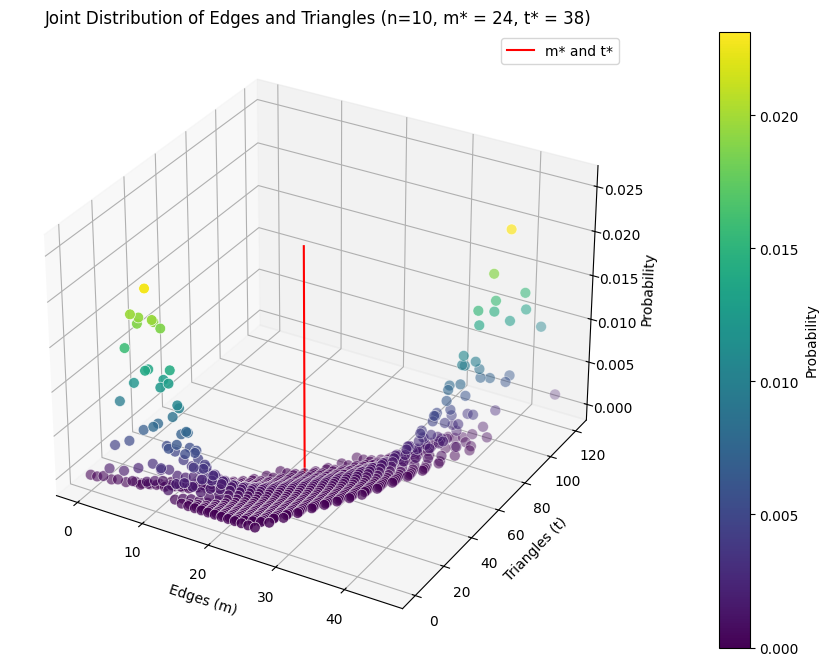

In [32]:
m_star = 24
t_star = 38
#unpack df to exact_dist
n10_dist = {}
for _, row in df.iterrows():
    m = int(row['Edges'])
    t = int(row['Triangles'])
    count = int(row['Count'])
    n10_dist[(m, t)] = count
try:
    roots = find_parameters(n, m_star, t_star, n10_dist)
    print(f"Parameters found: alpha={roots[0]}, beta={roots[1]}, gamma={roots[2]}")
    
    # 4. Plot the distribution (assuming plot_distribution is defined)
    plot_distribution(roots[0], roots[1], roots[2], n10_dist, m_star=m_star, t_star=t_star)
    
except Exception as e:
    print(f"Could not solve/plot for m={m_star}, t={t_star}: {e}")

[[3.10527209e-06 1.90381662e-06 1.15645707e-06 ... 1.44561228e-45
  3.61023327e-46 8.93300649e-47]
 [5.39952055e-06 3.34597020e-06 2.05431902e-06 ... 7.08801832e-45
  1.78916208e-45 4.47459247e-46]
 [9.27370432e-06 5.80846708e-06 3.60453102e-06 ... 3.43273551e-44
  8.75803373e-45 2.21386856e-45]
 ...
 [7.11873857e-08 1.23068232e-07 2.10798652e-07 ... 1.55399401e-03
  1.09433488e-03 7.63537009e-04]
 [3.74094941e-08 6.53681465e-08 1.13169515e-07 ... 2.30274367e-03
  1.63903383e-03 1.15587051e-03]
 [1.94179391e-08 3.42948484e-08 6.00113765e-08 ... 3.37042263e-03
  2.42475631e-03 1.72834637e-03]]


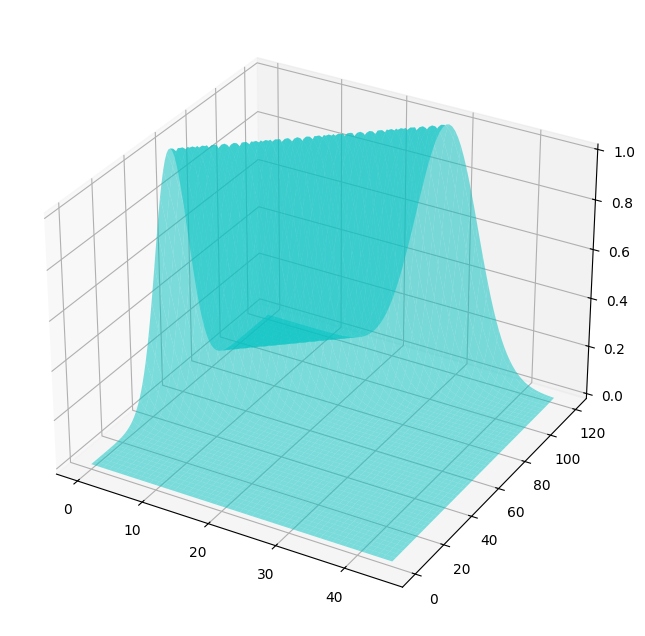

In [11]:
plot_curve(roots[0], roots[1], roots[2], n10_dist, m_star=m_star, t_star=t_star)

Parameters found: alpha=-3.8239758129334912685811374193988033458441154592601, beta=0.12020976702798047405269415951337350697980593046735, gamma=-0.049546530379634169880874699481338805648848507397399


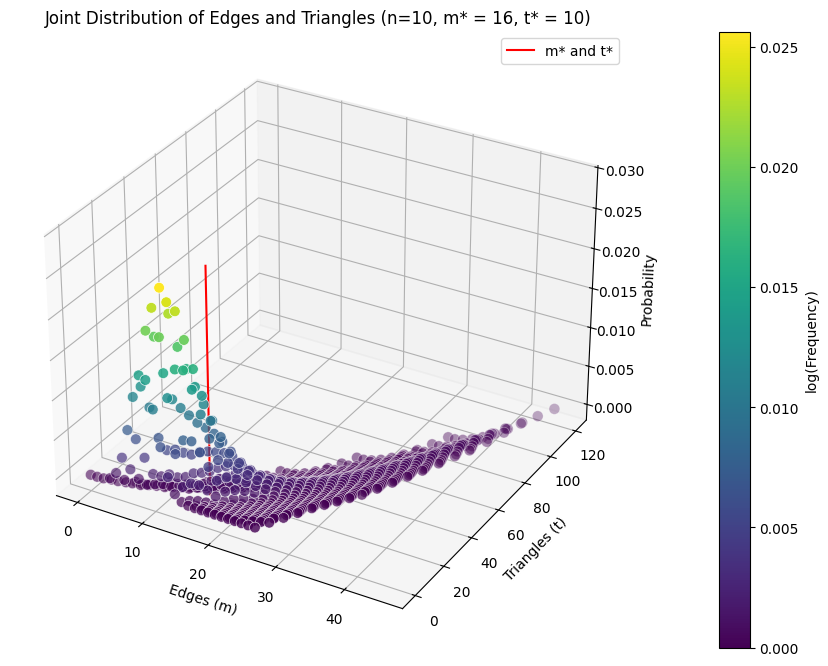

In [16]:
m_star = 16
t_star = 10
#unpack df to exact_dist
n10_dist = {}
for _, row in df.iterrows():
    m = int(row['Edges'])
    t = int(row['Triangles'])
    count = int(row['Count'])
    n10_dist[(m, t)] = count
try:
    roots = find_parameters(n, m_star, t_star, n10_dist)
    print(f"Parameters found: alpha={roots[0]}, beta={roots[1]}, gamma={roots[2]}")
    
    # 4. Plot the distribution (assuming plot_distribution is defined)
    plot_distribution(roots[0], roots[1], roots[2], n10_dist, m_star=m_star, t_star=t_star)
    
except Exception as e:
    print(f"Could not solve/plot for m={m_star}, t={t_star}: {e}")

[[4.46069522e-07 2.92831975e-07 1.91091412e-07 ... 6.99945472e-37
  2.57473507e-37 9.41472443e-38]
 [7.03576416e-07 4.64919241e-07 3.05386963e-07 ... 2.08666196e-36
  7.72628528e-37 2.84378072e-37]
 [1.10176049e-06 7.32830848e-07 4.84537078e-07 ... 6.17599860e-36
  2.30184528e-36 8.52809041e-37]
 ...
 [1.82063952e-02 2.25901482e-02 2.78625539e-02 ... 1.88089679e-05
  1.30771310e-05 9.03788284e-06]
 [1.42643151e-02 1.78154313e-02 2.21181338e-02 ... 2.78529432e-05
  1.94925610e-05 1.35604292e-05]
 [1.10954541e-02 1.39489269e-02 1.74318403e-02 ... 4.09491054e-05
  2.88464602e-05 2.01998136e-05]]


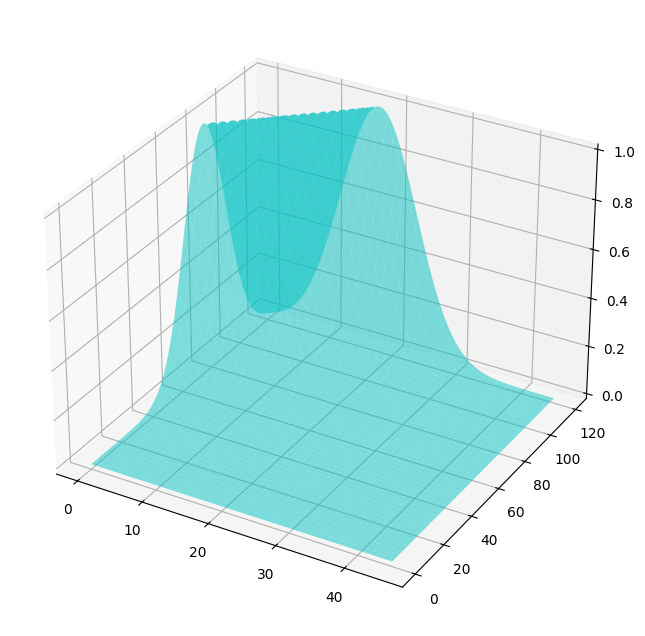

In [17]:
plot_curve(roots[0], roots[1], roots[2], n10_dist, m_star=m_star, t_star=t_star)

Parameters found: alpha=-16.436147901308564798451684363852223732976719187904, beta=-0.55123422453064887129340283184171737819079472132823, gamma=0.21539127787748770878098976386550882528297680808944


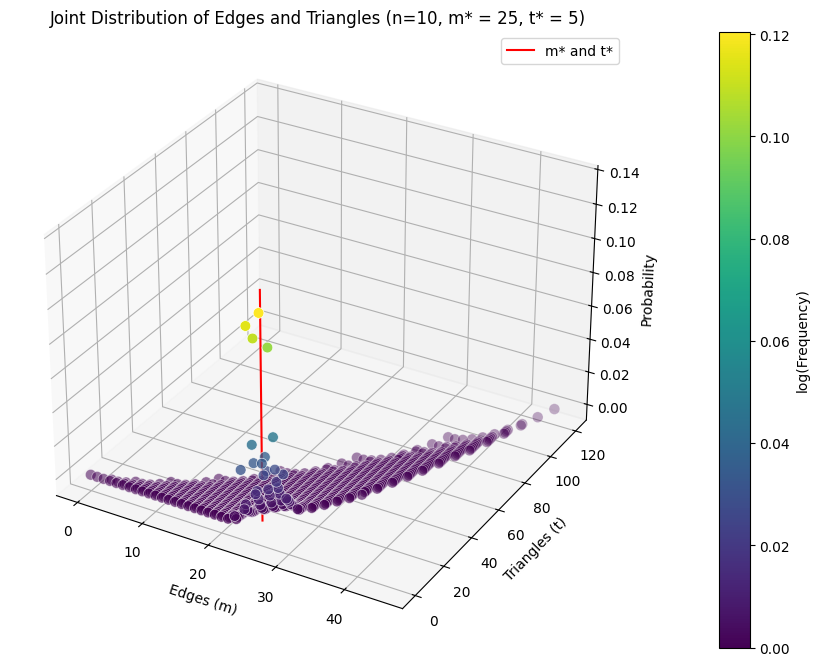

In [27]:
m_star = 25
t_star = 5
#unpack df to exact_dist
n10_dist = {}
for _, row in df.iterrows():
    m = int(row['Edges'])
    t = int(row['Triangles'])
    count = int(row['Count'])
    n10_dist[(m, t)] = count
try:
    roots = find_parameters(n, m_star, t_star, n10_dist)
    print(f"Parameters found: alpha={roots[0]}, beta={roots[1]}, gamma={roots[2]}")
    
    # 4. Plot the distribution (assuming plot_distribution is defined)
    plot_distribution(roots[0], roots[1], roots[2], n10_dist, m_star=m_star, t_star=t_star)
    
except Exception as e:
    print(f"Could not solve/plot for m={m_star}, t={t_star}: {e}")

[[4.74970799e-118 1.68451489e-114 5.26928963e-111 ... 1.29708817e-027
  2.36209227e-029 3.79396650e-031]
 [8.31408038e-122 3.36079683e-118 1.19822830e-114 ... 7.37337179e-026
  1.53043042e-027 2.80175606e-029]
 [1.26986031e-125 5.85064955e-122 2.37750530e-118 ... 3.65727139e-024
  8.65216399e-026 1.80535066e-027]
 ...
 [0.00000000e+000 0.00000000e+000 0.00000000e+000 ... 4.54323756e-133
  2.68684203e-129 1.40148383e-125]
 [0.00000000e+000 0.00000000e+000 0.00000000e+000 ... 4.66789286e-137
  3.14642702e-133 1.87061201e-129]
 [0.00000000e+000 0.00000000e+000 0.00000000e+000 ... 4.18476171e-141
  3.21504912e-137 2.17858127e-133]]


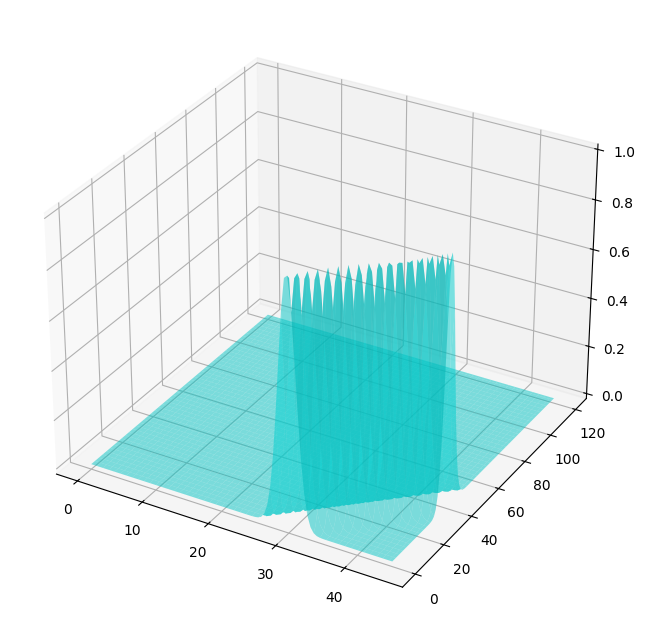

In [28]:
plot_curve(roots[0], roots[1], roots[2], n10_dist, m_star=m_star, t_star=t_star)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
def run_chain_history(G, m, t, n, alpha, beta, gamma):
    steps=100000
    current_m = m
    current_t = t
    H_old_sq = (alpha - beta * current_m - gamma * current_t) ** 2
    
    m_history = []
    t_history = []
    
    for _ in range(steps):
        i, j = np.random.randint(0, n, 2)
        while i == j: i, j = np.random.randint(0, n, 2)
        
        is_edge = G.has_edge(i, j)
        common = G.number_of_common_neighbors(i, j)
        
        delta_m = -1 if is_edge else 1
        delta_t = -common if is_edge else common 
        
        m_prop = current_m + delta_m
        t_prop = current_t + delta_t
        
        H_new_sq = (alpha - beta * m_prop - gamma * t_prop) ** 2
        dH = H_old_sq - H_new_sq 
        
        if np.log(np.random.uniform()) <= dH:
            if is_edge: G.remove_edge(i, j)
            else: G.add_edge(i, j)
            
            current_m = m_prop
            current_t = t_prop
            H_old_sq = H_new_sq
            
        m_history.append(current_m)
        t_history.append(current_t)s
        
    return m_history, t_history


Running 10 chains...
0
1
2
3
4
5
6
7
8
9


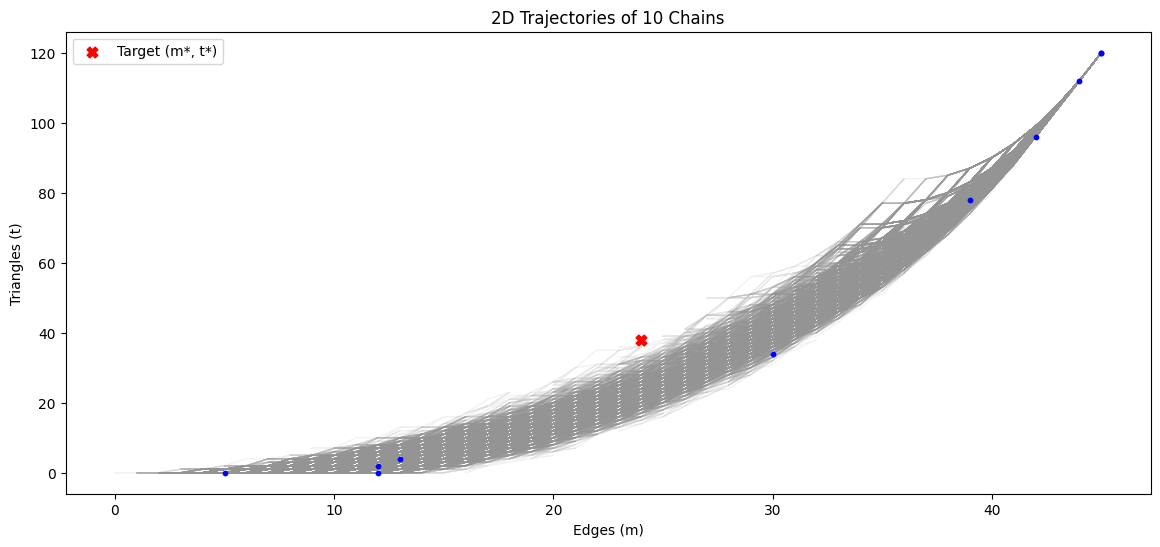

In [112]:
num_chains = 10
all_m_history = []
all_t_history = []

print(f"Running {num_chains} chains...")

for i in range(num_chains):
    print(i)
    p =np.random.uniform(0, 1)
    G = graphWithComplement(n, p=p)
    current_m = G.graph.number_of_edges()
    current_t = sum(nx.triangles(G.graph).values()) // 3
    
    m_hist, t_hist = run_chain_history(G, current_m, current_t, n, roots[0], roots[1], roots[2])
    
    all_m_history.append(m_hist)
    all_t_history.append(t_hist)

fig = plt.figure(figsize=(14, 6))

for k in range(num_chains):
    plt.plot(all_m_history[k], all_t_history[k], 
             color='black', alpha=0.05, linewidth=1)
    plt.scatter(all_m_history[k][0], all_t_history[k][0], color='blue', s=10, zorder=3)

plt.scatter([m_star], [t_star], color='red', marker='X', s=60, label='Target (m*, t*)', zorder=5)
    
plt.title(f"2D Trajectories of {num_chains} Chains")
plt.xlabel("Edges (m)")
plt.ylabel("Triangles (t)")
plt.legend()
plt.show()

/home/hartd2003/IIB/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


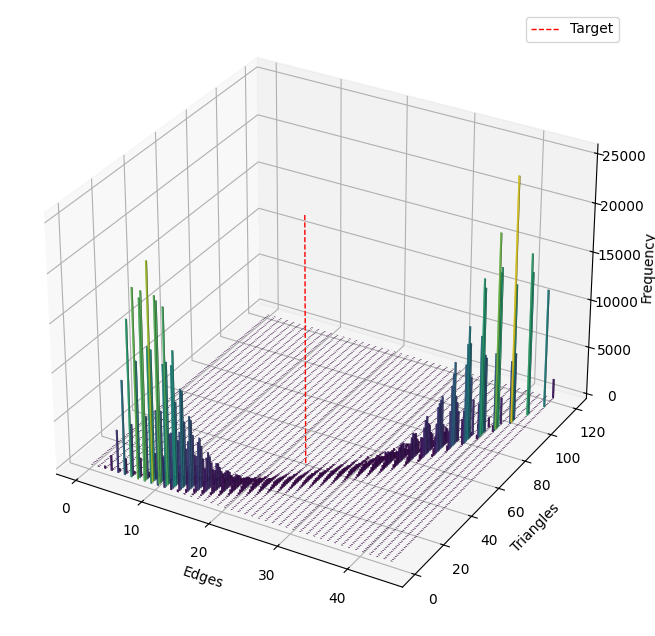

In [113]:
import matplotlib.pyplot as plt
import numpy as np

flat_m = [m for chain in all_m_history for m in chain]
flat_t = [t for chain in all_t_history for t in chain]
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
hist, xedges, yedges = np.histogram2d(flat_m, flat_t, bins=[45, 120])

xpos, ypos = np.meshgrid(xedges[:-1] + 0.25, yedges[:-1] + 0.25, indexing="ij")
xpos = xpos.ravel()
ypos = ypos.ravel()
zpos = 0

dx = dy = 0.25 * np.ones_like(zpos)
dz = hist.ravel()

cmap = plt.cm.viridis
max_height = np.max(dz)
min_height = np.min(dz)
colors = [cmap((k-min_height)/max_height) for k in dz]

ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color=colors, zsort='average', alpha=0.8)

ax.plot([m_star]*2, [t_star]*2, [0, max_height], color='red', linewidth=1, linestyle = '--', label='Target', zorder=100)

ax.set_xlabel('Edges')
ax.set_ylabel('Triangles')
ax.set_zlabel('Frequency')
plt.legend()

plt.show()

In [ ]:
import mpmath
mpmath.dps = 50
mpmath.mp.dps = 50

def find_ergm_parameters(n, m_star, t_star, exact_dist=exact_dist, alpha_start = 0.1, beta_start = 0.1, gamma_start = 0.1):
    def equations(alpha, beta, gamma):
        total_prob = 0
        prev_total_prob = -1
        expected_edges = 0
        expected_triangles = 0
        prev_expected_edges = -1
        #print(f"Trying alpha={alpha}, beta={beta}, gamma={gamma}")
        for (m, t), count in sorted(exact_dist.items()):
            term = alpha - beta * m - gamma * t
            prob_m_edges = count * mpmath.exp(-term)
            total_prob += prob_m_edges
            expected_edges += m * prob_m_edges
            expected_triangles += t * prob_m_edges
        return [total_prob - 1, expected_edges - m_star, expected_triangles - t_star]
    roots = mpmath.findroot(equations, [alpha_start, beta_start, gamma_start],tol=1e-4, maxsteps = 1000)
    return roots

In [18]:
import matplotlib.pyplot as plt
def plot_ergm_distribution(alpha, beta, gamma, exact_dist=exact_dist, m_star=None, t_star=None):
    m_vals, t_vals, raw_probs = zip(*[(m, t, c*mpmath.exp(-(alpha - beta * m - gamma * t))) for (m, t), c in exact_dist.items()])

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    probs = [float(p) for p in raw_probs]
    scatter = ax.scatter(m_vals, t_vals, probs, 
                            c=probs, cmap='viridis', 
                            s=60, edgecolors='w', linewidth=0.5)

    ax.set_xlabel('Edges (m)')
    ax.set_ylabel('Triangles (t)')
    ax.set_zlabel('Probability')
    plt.colorbar(scatter, label='Probability', pad=0.1)
    if m_star is not None and t_star is not None:
        plt.title(f'ERGM Joint Distribution of Edges and Triangles (n={n}, m* = {m_star}, t* = {t_star})')
        #add a vertical line with increasing z at m_star, t_star
        ax.plot([m_star]*2, [t_star]*2, [0, 1.1*max(probs)], color='red', label='m* and t*')
        plt.legend()
    plt.show()


In [19]:
import matplotlib.pyplot as plt
import numpy as np
import mpmath
mpmath.dps = 50
def plot_ergm_curve(alpha, beta, gamma, exact_dist=exact_dist, m_star=None, t_star=None):
    m_vals, t_vals, raw_probs = zip(*[(m, t, c*mpmath.exp(-(alpha - beta * m - gamma * t))) for (m, t), c in exact_dist.items()])
    alpha, beta, gamma = float(alpha), float(beta), float(gamma)
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    #plot exp(-(alpha - beta*m - gamma*t)^2) curve
    m_curve = np.linspace(min(m_vals), max(m_vals), 100)
    t_curve = np.linspace(min(t_vals), max(t_vals), 100)
    M, T = np.meshgrid(m_curve, t_curve)
    Z_raw = np.exp(-(alpha - beta * M - gamma * T))
    Z = np.array(Z_raw, dtype=float)
    ax.plot_surface(M, T, Z, color='cyan', alpha=0.5)
    
    plt.show()

Parameters found: alpha=10.042789331328972625600129192197547381191597793516, beta=-1.5173589826828047283956350368639775318027620257391, gamma=0.62161632622792458550704492791254455915075249260985


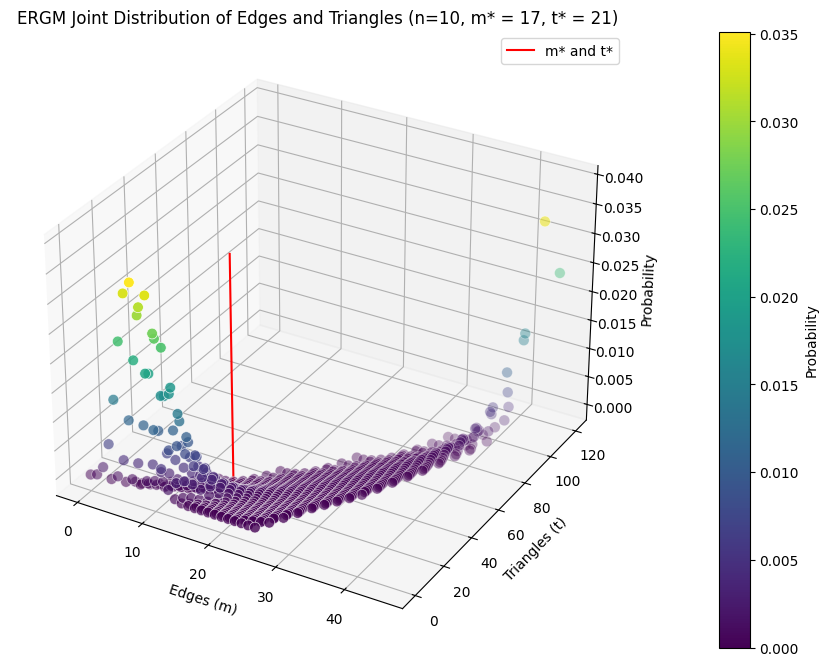

In [20]:
m_star = 17
t_star = 21
#unpack df to exact_dist
n10_dist = {}
for _, row in df.iterrows():
    m = int(row['Edges'])
    t = int(row['Triangles'])
    count = int(row['Count'])
    n10_dist[(m, t)] = count
try:
    roots = find_ergm_parameters(n, m_star, t_star, n10_dist)
    print(f"Parameters found: alpha={roots[0]}, beta={roots[1]}, gamma={roots[2]}")
    
    # 4. Plot the distribution (assuming plot_distribution is defined)
    plot_ergm_distribution(roots[0], roots[1], roots[2], n10_dist, m_star=m_star, t_star=t_star)
    
except Exception as e:
    print(f"Could not solve/plot for m={m_star}, t={t_star}: {e}")

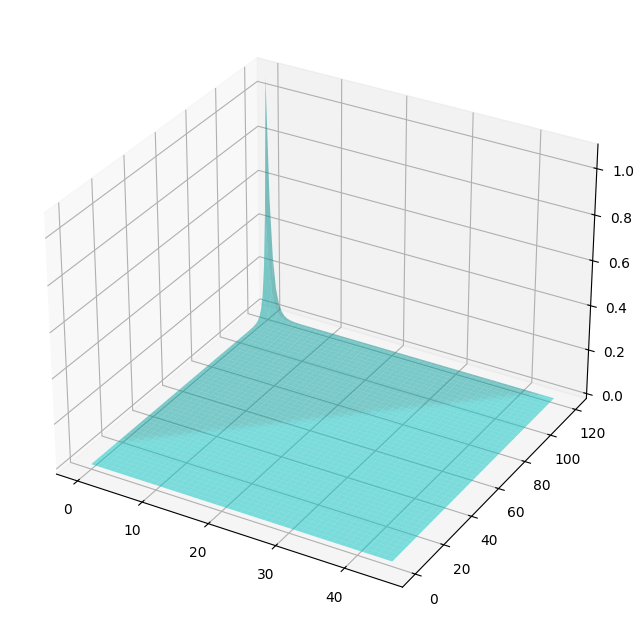

In [118]:
plot_ergm_curve(roots[0], roots[1], roots[2], n10_dist, m_star=m_star, t_star=t_star)

Parameters found: alpha=13.258522626507119860919926313325221560145629486265, beta=-1.9024131359406677995046570687255804180700868609637, gamma=0.81989643777076721037228525423167177802577963410915


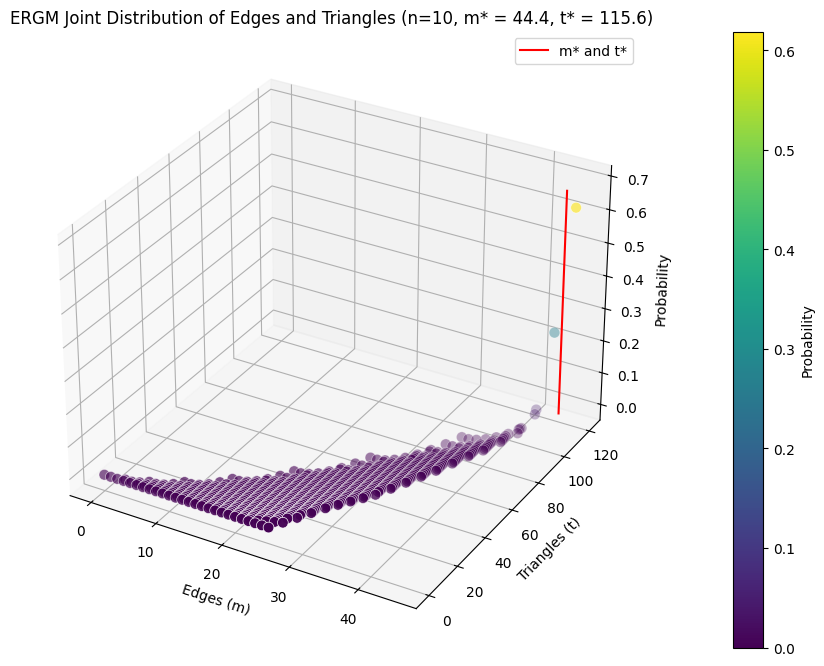

In [41]:
m_star = 44.4
t_star = 115.6
#unpack df to exact_dist
n10_dist = {}
for _, row in df.iterrows():
    m = int(row['Edges'])
    t = int(row['Triangles'])
    count = int(row['Count'])
    n10_dist[(m, t)] = count
try:
    roots = find_ergm_parameters(n, m_star, t_star, n10_dist,alpha_start = -83, beta_start = 0.5, gamma_start = 0.5)
    print(f"Parameters found: alpha={roots[0]}, beta={roots[1]}, gamma={roots[2]}")
    
    # 4. Plot the distribution (assuming plot_distribution is defined)
    plot_ergm_distribution(roots[0], roots[1], roots[2], n10_dist, m_star=m_star, t_star=t_star)
    
except Exception as e:
    print(f"Could not solve/plot for m={m_star}, t={t_star}: {e}")

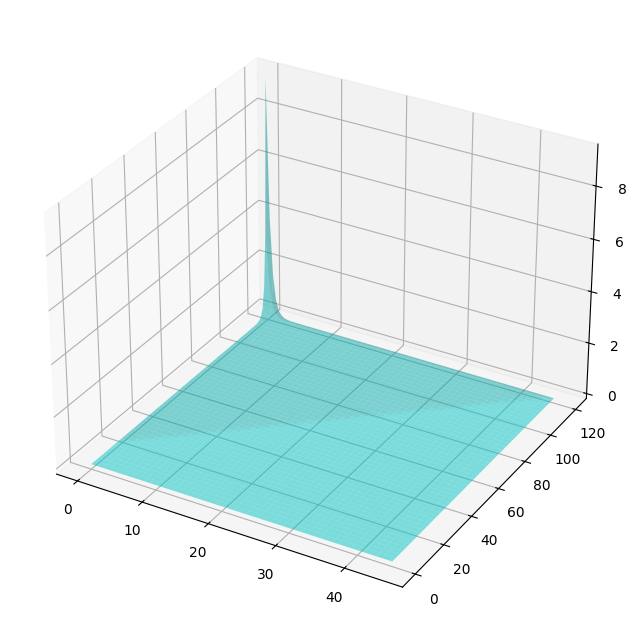

In [42]:
plot_ergm_curve(roots[0], roots[1], roots[2], n10_dist, m_star=m_star, t_star=t_star)

In [119]:
import matplotlib.pyplot as plt
import numpy as np
def run_ergm_chain_history(G, m, t, n, alpha, beta, gamma):
    steps=100000
    current_m = m
    current_t = t
    
    m_history = []
    t_history = []
    
    for _ in range(steps):
        i, j = np.random.randint(0, n, 2)
        while i == j: i, j = np.random.randint(0, n, 2)
        
        is_edge = G.has_edge(i, j)
        common = G.number_of_common_neighbors(i, j)
        
        delta_m = -1 if is_edge else 1
        delta_t = -common if is_edge else common 
        
        m_prop = current_m + delta_m
        t_prop = current_t + delta_t
        
        dH = beta*delta_m + gamma*delta_t
        
        if np.log(np.random.uniform()) <= dH:
            if is_edge: G.remove_edge(i, j)
            else: G.add_edge(i, j)
            
            current_m = m_prop
            current_t = t_prop
            
        m_history.append(current_m)
        t_history.append(current_t)
        
    return m_history, t_history


Running 10 chains...
0
1
2
3
4
5
6
7
8
9


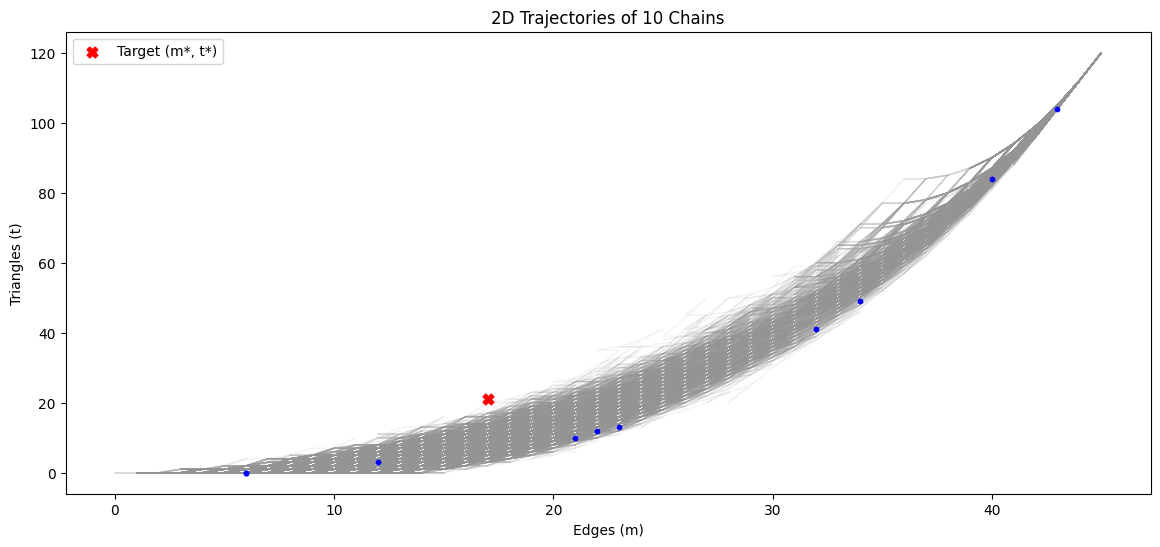

In [120]:
num_chains = 10
all_m_history = []
all_t_history = []

print(f"Running {num_chains} chains...")

for i in range(num_chains):
    print(i)
    p =np.random.uniform(0, 1)
    G = graphWithComplement(n, p=p)
    current_m = G.graph.number_of_edges()
    current_t = sum(nx.triangles(G.graph).values()) // 3
    
    m_hist, t_hist = run_ergm_chain_history(G, current_m, current_t, n, roots[0], roots[1], roots[2])
    
    all_m_history.append(m_hist)
    all_t_history.append(t_hist)

fig = plt.figure(figsize=(14, 6))

for k in range(num_chains):
    plt.plot(all_m_history[k], all_t_history[k], 
             color='black', alpha=0.05, linewidth=1)
    plt.scatter(all_m_history[k][0], all_t_history[k][0], color='blue', s=10, zorder=3)

plt.scatter([m_star], [t_star], color='red', marker='X', s=60, label='Target (m*, t*)', zorder=5)
    
plt.title(f"2D Trajectories of {num_chains} Chains")
plt.xlabel("Edges (m)")
plt.ylabel("Triangles (t)")
plt.legend()
plt.show()

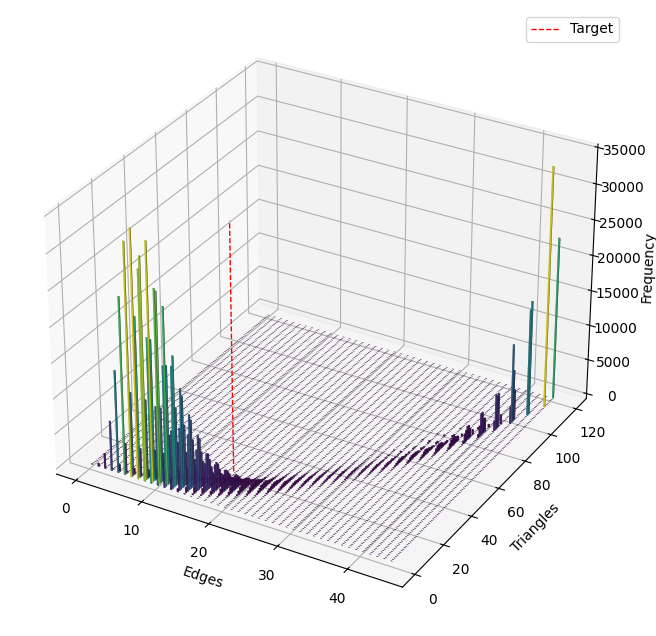

In [121]:
import matplotlib.pyplot as plt
import numpy as np

flat_m = [m for chain in all_m_history for m in chain]
flat_t = [t for chain in all_t_history for t in chain]
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
hist, xedges, yedges = np.histogram2d(flat_m, flat_t, bins=[45, 120])

xpos, ypos = np.meshgrid(xedges[:-1] + 0.25, yedges[:-1] + 0.25, indexing="ij")
xpos = xpos.ravel()
ypos = ypos.ravel()
zpos = 0

dx = dy = 0.25 * np.ones_like(zpos)
dz = hist.ravel()

cmap = plt.cm.viridis
max_height = np.max(dz)
min_height = np.min(dz)
colors = [cmap((k-min_height)/max_height) for k in dz]

ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color=colors, zsort='average', alpha=0.8)

ax.plot([m_star]*2, [t_star]*2, [0, max_height], color='red', linewidth=1, linestyle = '--', label='Target', zorder=100)

ax.set_xlabel('Edges')
ax.set_ylabel('Triangles')
ax.set_zlabel('Frequency')
plt.legend()

plt.show()

In [1]:
import pandas as pd

n=10
df = pd.read_csv(f'joint_distribution_n{n}.csv')
df.head()

,Edges,Triangles,Count
0,0,0,1
1,1,0,45
2,2,0,990
3,3,0,14070
4,3,1,120


In [2]:
import matplotlib.pyplot as plt
import numpy as np

def get_line_slice_projected(dist_dict, alpha, beta, gamma, tolerance=1.0):
    slice_points = []
    # The normal vector to the line (-beta*m - gamma*t + alpha = 0) is (-beta, -gamma)
    norm_mag = np.sqrt(beta**2 + gamma**2)
    
    # Tangent vector (direction of the line)
    # If normal is (-beta, -gamma), tangent is (gamma, -beta)
    # We normalize this to get unit steps along the line
    tan_m = gamma / norm_mag
    tan_t = -beta / norm_mag
    
    # Standardize direction (e.g., always left-to-right)
    if tan_m < 0:
        tan_m = -tan_m
        tan_t = -tan_t
    elif tan_m == 0 and tan_t < 0:
        tan_t = -tan_t

    for (m, t), count in dist_dict.items():
        # Perpendicular distance to line: |Ax + By + C| / sqrt(A^2 + B^2)
        # Equation: alpha - beta*m - gamma*t = 0
        perp_dist = abs(alpha - beta * m - gamma * t) / norm_mag
        
        if perp_dist <= tolerance:
            # Project point onto the line vector for 1D plotting
            pos_on_line = m * tan_m + t * tan_t
            
            slice_points.append({
                'm': m,
                't': t,
                'count': count,
                'pos': pos_on_line
            })
            
    slice_points.sort(key=lambda x: x['pos'])
    return slice_points

def plot_combinatorial_slice(dist_dict, alpha, beta, gamma, tolerance=1.0):
    m_all = [k[0] for k in dist_dict.keys()]
    t_all = [k[1] for k in dist_dict.keys()]
    
    # Using log counts for the background scatter helps visibility
    c_all = [np.log(v) if v > 0 else 0 for v in dist_dict.values()]

    slice_data = get_line_slice_projected(dist_dict, alpha, beta, gamma, tolerance)
    
    if not slice_data:
        print(f"No points found within tolerance {tolerance} of constraint.")
        return

    slice_m = [d['m'] for d in slice_data]
    slice_t = [d['t'] for d in slice_data]
    slice_counts = [d['count'] for d in slice_data]
    slice_pos = [d['pos'] for d in slice_data]

    fig, axes = plt.subplots(2, 1, figsize=(10, 12), gridspec_kw={'height_ratios': [2, 1]})
    
    # --- Top Plot: Phase Space ---
    ax_main = axes[0]
    ax_main.scatter(m_all, t_all, c=c_all, cmap='Greys', s=10, alpha=0.2, label='All Graphs')
    
    # Plot the theoretical line: alpha - beta*m - gamma*t = 0  =>  gamma*t = alpha - beta*m
    x_range = np.linspace(min(m_all), max(m_all), 100)
    
    if gamma != 0:
        y_line = (alpha - beta * x_range) / gamma
        ax_main.plot(x_range, y_line, 'b--', lw=1.5, label=f'{alpha:.2f} - {beta:.2f}m - {gamma:.2f}t = 0')
    else:
        # Vertical line case if gamma is 0
        if beta != 0:
            x_line = alpha / beta
            ax_main.axvline(x_line, color='b', linestyle='--', lw=1.5, label=f'm = {x_line:.2f}')
    
    # Highlight the sliced points
    ax_main.scatter(slice_m, slice_t, color='red', s=40, edgecolors='k', zorder=5, label='Slice')
    
    ax_main.set_xlabel('Edges (m)')
    ax_main.set_ylabel('Triangles (t)')
    ax_main.set_title(f'Slice along constraint')
    ax_main.legend()
    ax_main.grid(True, alpha=0.3)

    # --- Bottom Plot: Density Profile ---
    ax_slice = axes[1]
    
    # Plotting Counts vs Projected Position
    ax_slice.scatter(slice_pos, slice_counts, color='red', s=20, alpha=0.8)
    
    ax_slice.set_xlabel('Position along slice line (Projected Euclidean Distance)')
    ax_slice.set_ylabel('Combinatorial Count N(m,t)')
    ax_slice.set_title('Density Variation Along Constraint')
    ax_slice.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

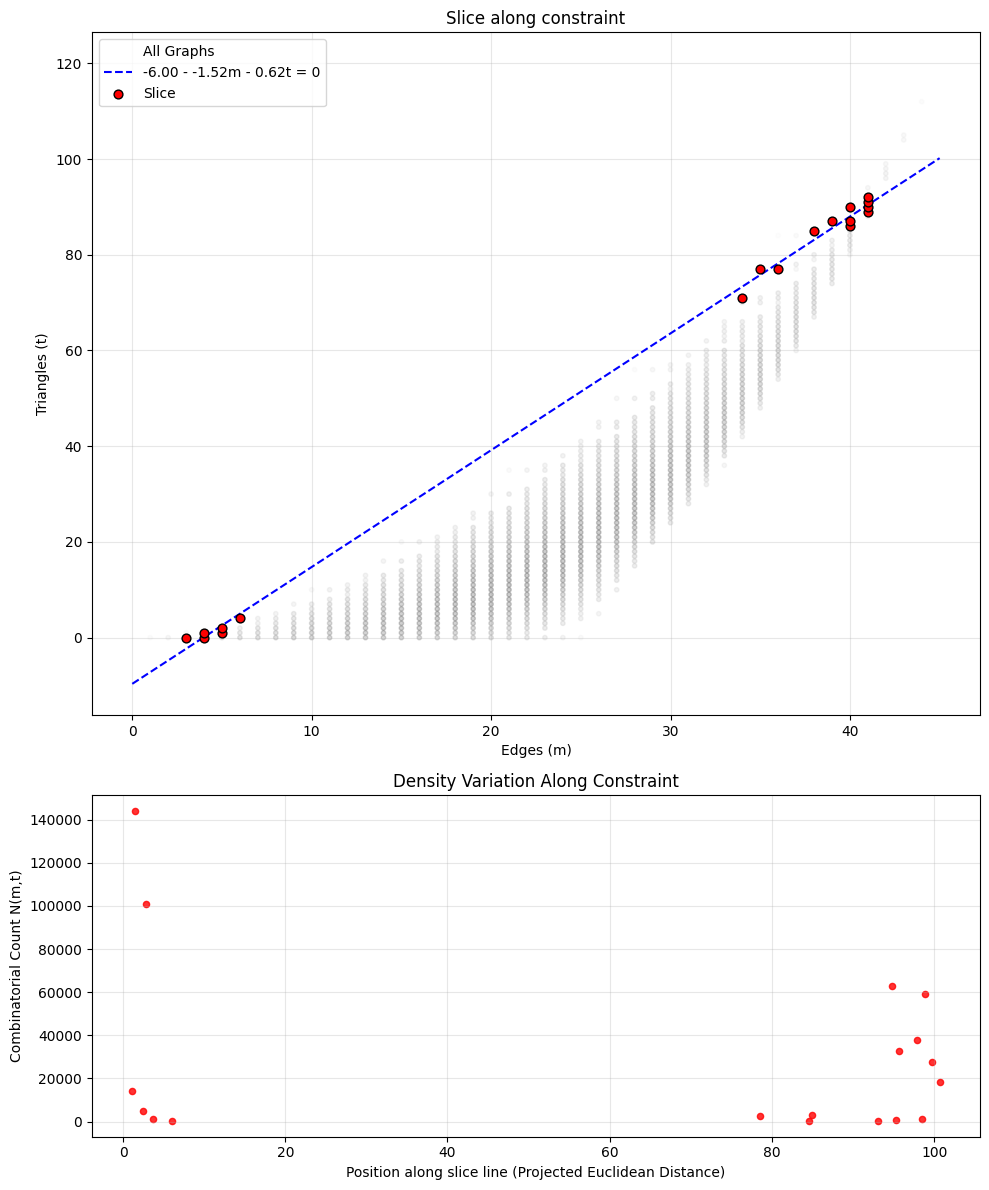

In [21]:
dist_dict = {}
for _, row in df.iterrows():
    m = int(row['Edges'])
    t = int(row['Triangles'])
    count = int(row['Count'])
    dist_dict[(m, t)] = count

alpha=-6
beta=-1.5173589826828047283956350368639775318027620257391
gamma=0.62161632622792458550704492791254455915075249260985

plot_combinatorial_slice(dist_dict, alpha, beta, gamma, tolerance=0.9)


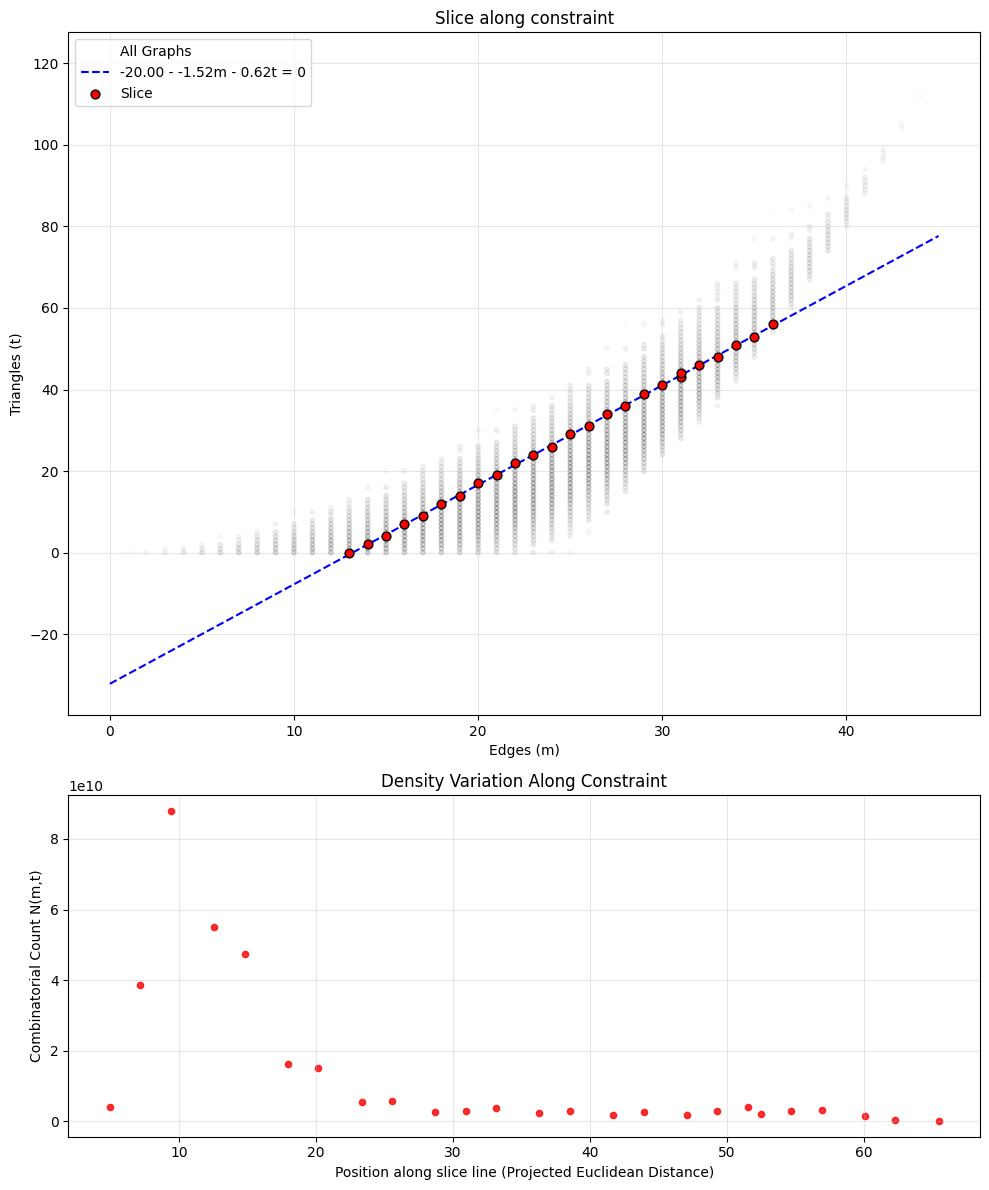

In [9]:

alpha=-20
beta=-1.5173589826828047283956350368639775318027620257391
gamma=0.62161632622792458550704492791254455915075249260985

plot_combinatorial_slice(dist_dict, alpha, beta, gamma, tolerance=0.2)

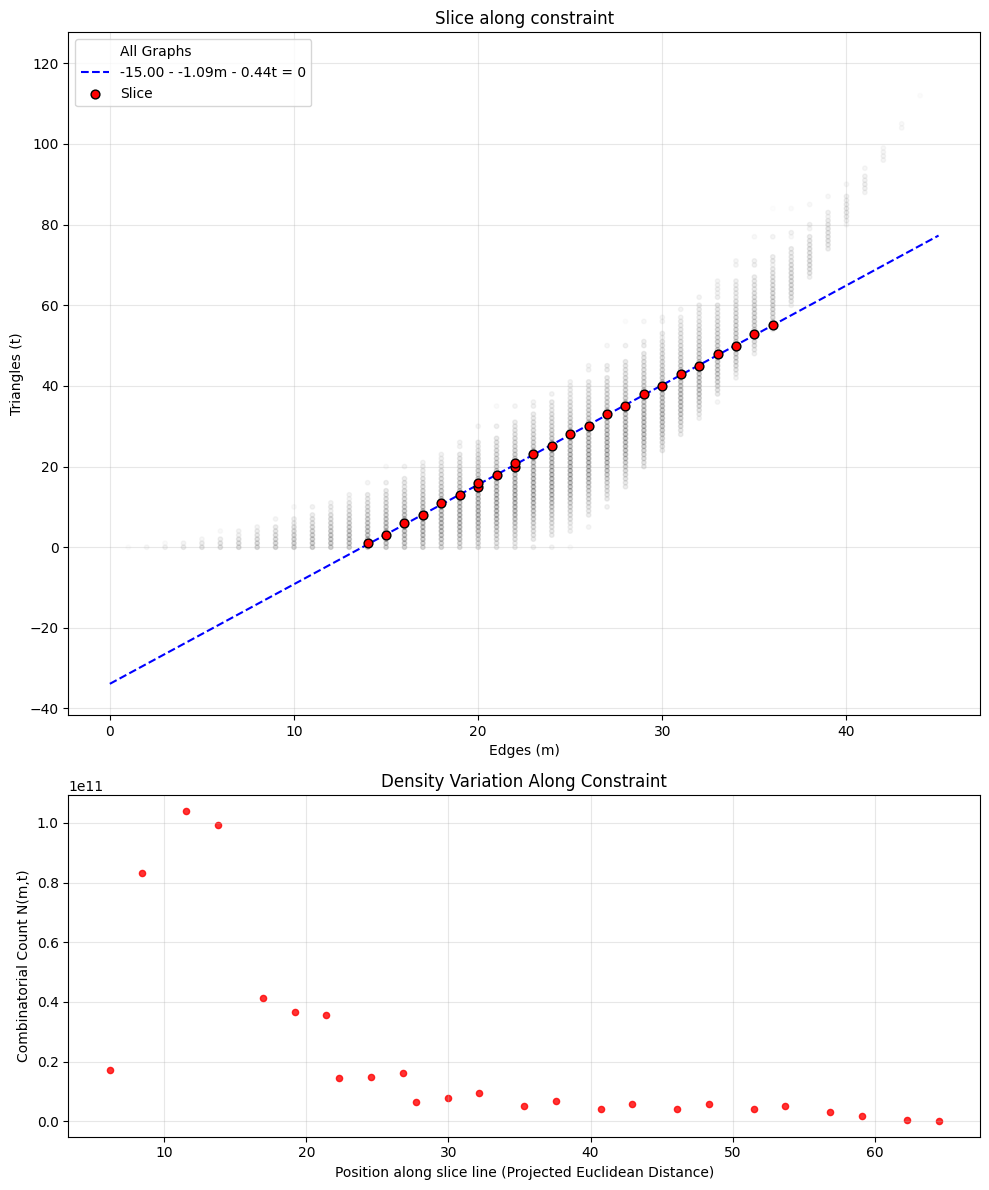

In [23]:
alpha=-15
beta=-1.093718098379835295715143683159261510806344570041
gamma=0.4427012440242592082495550078480961461633524150344

plot_combinatorial_slice(dist_dict, alpha, beta, gamma, tolerance=0.2)

In [33]:
import mpmath
import numpy as np

# Ensure high precision for exponentials
mpmath.mp.dps = 50

def reverse_engineer_parameters(dist_dict, target_beta, target_gamma):
    """
    Calculates the exact m*, t*, and alpha that correspond to the given
    beta and gamma parameters for the distribution dist_dict.
    """
    Z_partial = mpmath.mpf(0)      # Sum of count * exp(beta*m + gamma*t)
    exp_m_num = mpmath.mpf(0)      # Numerator for E[m]
    exp_t_num = mpmath.mpf(0)      # Numerator for E[t]
    
    # Convert inputs to high precision
    beta = mpmath.mpf(target_beta)
    gamma = mpmath.mpf(target_gamma)
    
    print(f"Calculating moments for Beta={beta}, Gamma={gamma}...")
    
    for (m, t), count in dist_dict.items():
        # Calculate term w/o alpha: count * exp(beta*m + gamma*t)
        # Note: Your solver uses exp(alpha + beta*m + gamma*t).
        # We compute the sum for the exp(beta*m + gamma*t) part first.
        term = mpmath.exp(beta * m + gamma * t)
        weight = count * term
        
        Z_partial += weight
        exp_m_num += m * weight
        exp_t_num += t * weight
        
    # 1. Calculate Expected Moments (Target m* and t*)
    m_star = float(exp_m_num / Z_partial)
    t_star = float(exp_t_num / Z_partial)
    
    # 2. Calculate Alpha
    # Since sum(P) = 1 => exp(alpha) * Z_partial = 1
    # alpha = -ln(Z_partial)
    alpha = float(-mpmath.log(Z_partial))
    
    return m_star, t_star, alpha

# --- EXECUTION ---

# 1. Pick SAME SIGN parameters (To get negative slope slice)
#    Positive values -> Push to High Density (Complete Graph)
#    Negative values -> Push to Low Density (Empty Graph)
#    Try these values for a slice near the dense region:
target_beta = 0.5    
target_gamma = 0.5

# 2. Run calculation
try:
    m_out, t_out, alpha_out = reverse_engineer_parameters(n10_dist, target_beta, target_gamma)
    
    print("\n" + "="*40)
    print(f"RESULTS FOR SAME-SIGNED PARAMETERS")
    print(f"="*40)
    print(f"Target Parameters (Input):")
    print(f"  Beta  = {target_beta}")
    print(f"  Gamma = {target_gamma}")
    print(f"-"*40)
    print(f"Corresponding Exact Moments (Use these as m*, t*):")
    print(f"  m* = {m_out:.4f}")
    print(f"  t* = {t_out:.4f}")
    print(f"-"*40)
    print(f" recovered Alpha:")
    print(f"  Alpha = {alpha_out:.4f}")
    print(f"="*40)
    
    # Optional: Verify slope
    slope = -target_beta/target_gamma
    print(f"Constraint Line Slope: {slope:.2f}")
    print(f"Constraint Line: {alpha_out:.2f} + {target_beta}m + {target_gamma}t = 0")
    
except NameError:
    print("Error: 'n10_dist' dictionary not found. Please load your data first.")

Calculating moments for Beta=0.5, Gamma=0.5...

RESULTS FOR SAME-SIGNED PARAMETERS
Target Parameters (Input):
  Beta  = 0.5
  Gamma = 0.5
----------------------------------------
Corresponding Exact Moments (Use these as m*, t*):
  m* = 44.4387
  t* = 115.6025
----------------------------------------
 recovered Alpha:
  Alpha = -83.0289
Constraint Line Slope: -1.00
Constraint Line: -83.03 + 0.5m + 0.5t = 0


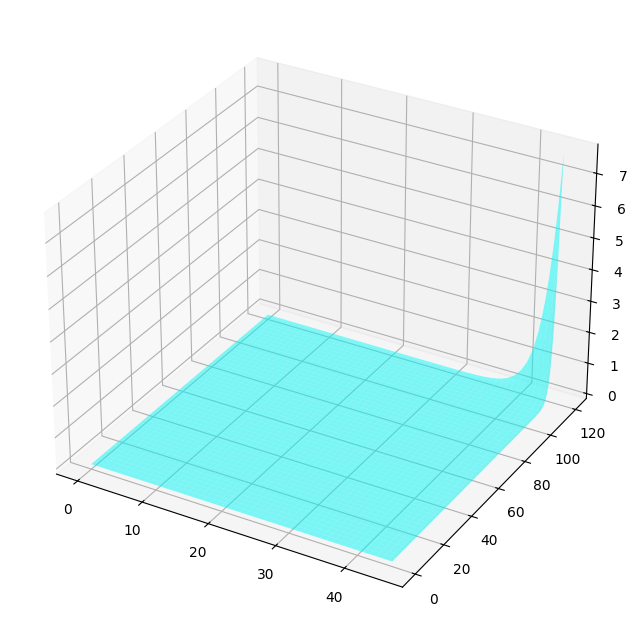

In [45]:
alpha = -83.0289
beta = 0.5
gamma = 0.5

plot_ergm_curve(alpha, beta, gamma, n10_dist, m_star=m_out, t_star=t_out)

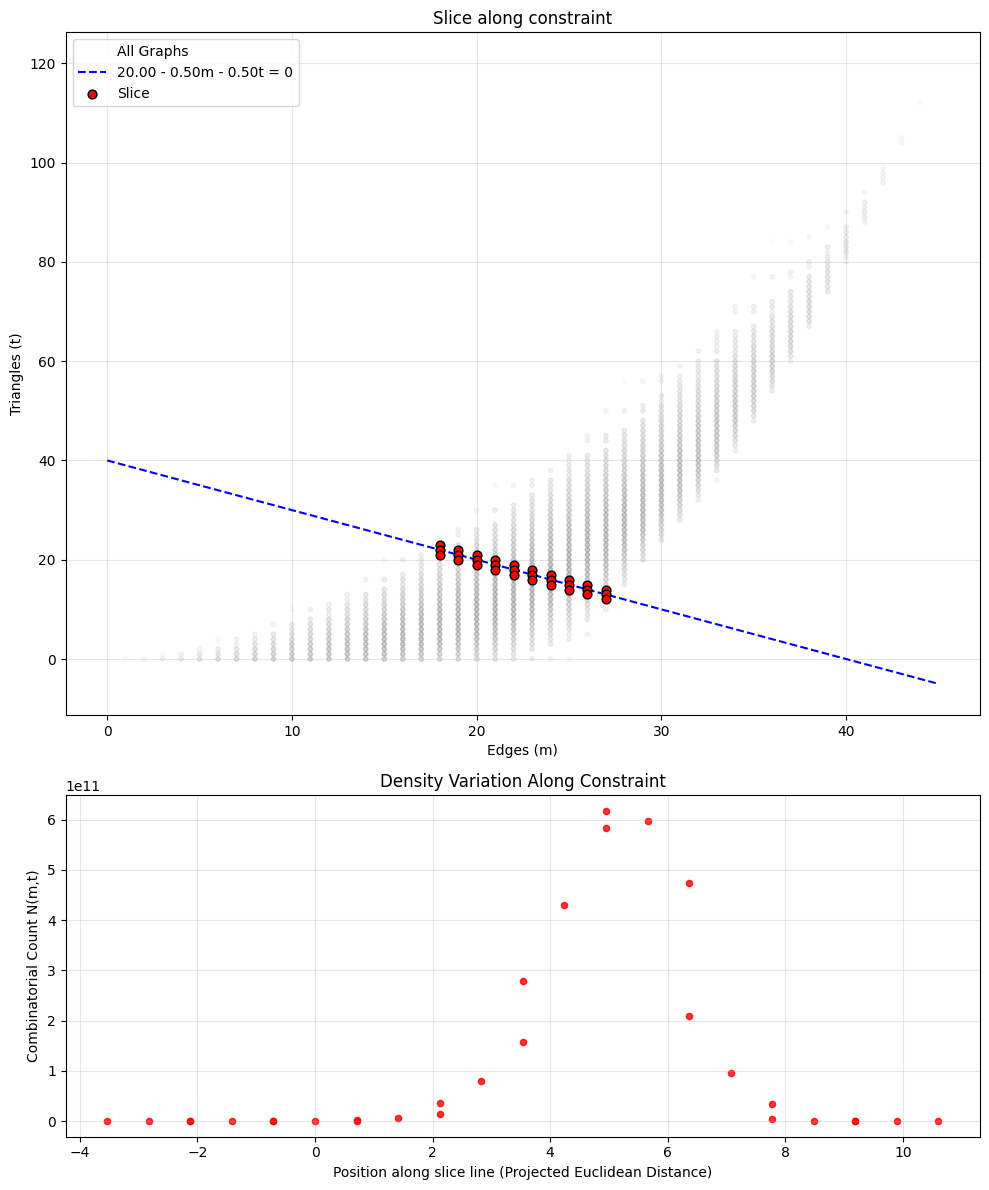

In [51]:
alpha = 20
plot_combinatorial_slice(n10_dist, alpha, beta, gamma, tolerance=1.0)

In [24]:
import mpmath

mpmath.dps = 50
mpmath.mp.dps = 50
exact_dist = dist_dict

def find_ergm_parameters_variance(n, m_star, t_star, var_m_star, var_t_star, exact_dist=exact_dist, 
                                  alpha_start=0.1, beta_start=0.1, gamma_start=0.1, 
                                  delta_start=0.01, epsilon_start=0.01):
    
    # Convert the target variance to the target raw second moment
    m_sq_star = var_m_star + (m_star ** 2)
    t_sq_star = var_t_star + (t_star ** 2)
    
    def equations(alpha, beta, gamma, delta, epsilon):
        total_prob = 0
        expected_edges = 0
        expected_triangles = 0
        expected_edges_sq = 0
        expected_triangles_sq = 0
        
        for (m, t), count in sorted(exact_dist.items()):
            term = alpha - beta * m - gamma * t - delta * (m**2) - epsilon * (t**2)
            prob_m_edges = count * mpmath.exp(-term)
            
            total_prob += prob_m_edges
            expected_edges += m * prob_m_edges
            expected_triangles += t * prob_m_edges
            expected_edges_sq += (m**2) * prob_m_edges
            expected_triangles_sq += (t**2) * prob_m_edges
            
        return [
            total_prob - 1, 
            expected_edges - m_star, 
            expected_triangles - t_star,
            expected_edges_sq - m_sq_star,
            expected_triangles_sq - t_sq_star
        ]

    roots = mpmath.findroot(
        equations, 
        [alpha_start, beta_start, gamma_start, delta_start, epsilon_start],
        tol=1e-4, 
        maxsteps=1000
    )
    
    return roots

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import mpmath
mpmath.dps = 50

def plot_ergm_curve_variance(alpha, beta, gamma, delta, epsilon, exact_dist=None, m_star=None, t_star=None):
    m_vals = [m for (m, t) in exact_dist.keys()]
    t_vals = [t for (m, t) in exact_dist.keys()]
    
    alpha, beta, gamma, delta, epsilon = map(float, [alpha, beta, gamma, delta, epsilon])
    
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    m_range = np.linspace(min(m_vals), max(m_vals), 100)
    t_range = np.linspace(min(t_vals), max(t_vals), 100)
    M, T = np.meshgrid(m_range, t_range)
    
    Z = np.exp(-(alpha - beta * M - gamma * T - delta * (M**2) - epsilon * (T**2)))
    Z = np.array(Z, dtype=float)
    
    ax.plot_surface(M, T, Z, color='cyan', alpha=0.5)
    
    if m_star is not None and t_star is not None:
        z_star = np.exp(-(alpha - beta * m_star - gamma * t_star - delta * (m_star**2) - epsilon * (t_star**2)))
        ax.scatter([m_star], [t_star], [float(z_star)], color='red', s=100, label='Target Mean')
        
    plt.show()


AttributeError: cannot set 'dps' on 'mpmath'. Did you mean to set 'dps' on 'mpmath.mp'?

In [28]:
import matplotlib.pyplot as plt
import mpmath

def plot_ergm_distribution_variance(alpha, beta, gamma, delta, epsilon, exact_dist=None, m_star=None, t_star=None, n=None):
    m_vals = []
    t_vals = []
    probs = []
    
    for (m, t), count in exact_dist.items():
        term = alpha - beta * m - gamma * t - delta * (m**2) - epsilon * (t**2)
        p = float(count * mpmath.exp(-term))
        m_vals.append(m)
        t_vals.append(t)
        probs.append(p)

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    scatter = ax.scatter(m_vals, t_vals, probs, 
                        c=probs, cmap='viridis', 
                        s=60, edgecolors='w', linewidth=0.5)

    ax.set_xlabel('Edges (m)')
    ax.set_ylabel('Triangles (t)')
    ax.set_zlabel('Probability')
    plt.colorbar(scatter, label='Probability', pad=0.1)
    
    if m_star is not None and t_star is not None:
        plt.title(f'ERGM Joint Distribution with 2nd Moments (n={n}, m*={m_star}, t*={t_star})')
        ax.plot([m_star]*2, [t_star]*2, [0, 1.1*max(probs)], color='red', label='Target Means', linewidth=2)
        plt.legend()
    
    plt.show()

Parameters found: alpha=50.299417608466318389144650683688876358746406155258, beta=0.042158023347306966159558797945124594575598031107467, gamma=4.7671766682783920509543847834750154305450576940839, delta=-0.11000158051195509031996119467340475822050686981688, epsilon=-0.069761530918729089878313168988634558910442601970531


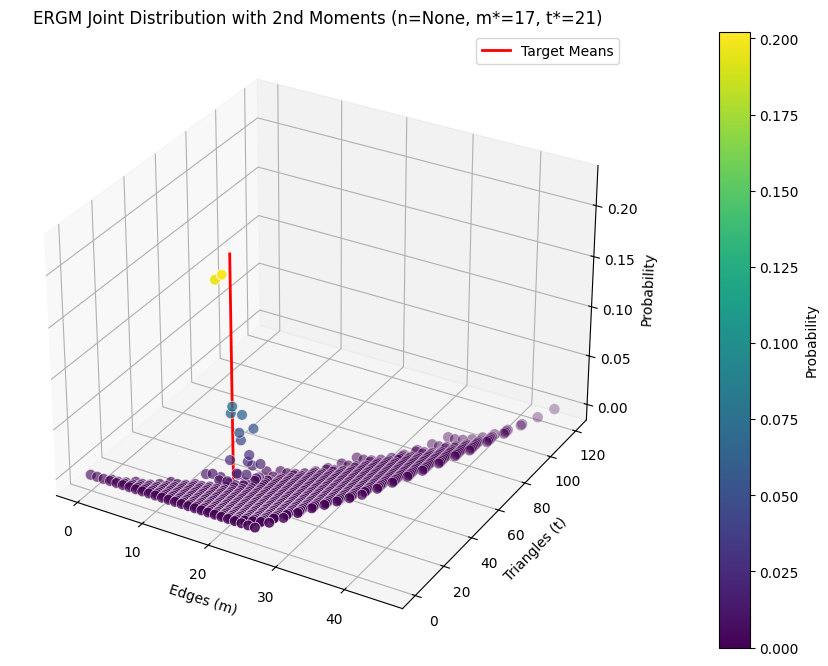

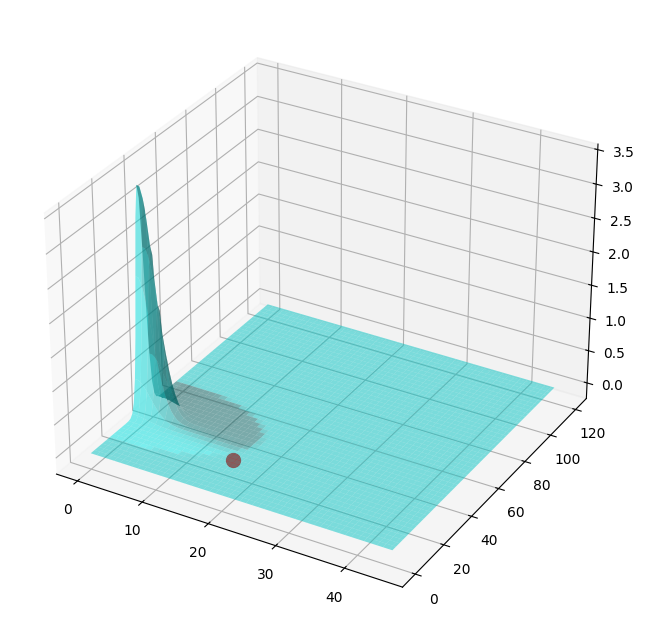

In [29]:
m_star = 17
t_star = 21
var_m_star = 2.5
var_t_star = 5.0

try:
    roots = find_ergm_parameters_variance(n, m_star, t_star, var_m_star, var_t_star, exact_dist)
    print(f"Parameters found: alpha={roots[0]}, beta={roots[1]}, gamma={roots[2]}, delta={roots[3]}, epsilon={roots[4]}")
    
    # 4. Plot the distribution (assuming plot_distribution is defined)
    plot_ergm_distribution_variance(roots[0], roots[1], roots[2], roots[3], roots[4], exact_dist, m_star=m_star, t_star=t_star)
    plot_ergm_curve_variance(roots[0], roots[1], roots[2], roots[3], roots[4], exact_dist, m_star=m_star, t_star=t_star)
    
except Exception as e:
    print(f"Could not solve/plot for m={m_star}, t={t_star}: {e}")

In [35]:
def get_ergm_variances(alpha, beta, gamma, exact_dist):
    expected_edges = 0
    expected_triangles = 0
    expected_edges_sq = 0
    expected_triangles_sq = 0
    total_prob = 0
    
    # Calculate probabilities and moments
    for (m, t), count in exact_dist.items():
        term = alpha - beta * m - gamma * t
        prob = count * mpmath.exp(-term)
        
        total_prob += prob
        expected_edges += m * prob
        expected_triangles += t * prob
        expected_edges_sq += (m**2) * prob
        expected_triangles_sq += (t**2) * prob
        
    # Normalize by total_prob to ensure accuracy (should be ~1.0)
    mu_m = expected_edges / total_prob
    mu_t = expected_triangles / total_prob
    mu_m2 = expected_edges_sq / total_prob
    mu_t2 = expected_triangles_sq / total_prob
    
    var_edges = mu_m2 - (mu_m**2)
    var_triangles = mu_t2 - (mu_t**2)
    
    return float(var_edges), float(var_triangles)

In [37]:
alpha=10.042789331328972625600129192197547381191597793516
beta=-1.5173589826828047283956350368639775318027620257391
gamma=0.62161632622792458550704492791254455915075249260985

var_m, var_t = get_ergm_variances(alpha, beta, gamma, exact_dist)
print(f"Variance of Edges: {var_m:.4f}")
print(f"Variance of Triangles: {var_t:.4f}")

Variance of Edges: 156.0183
Variance of Triangles: 1367.4886


Parameters found: alpha=10.93817711430308678333133854721350355676699309313, beta=-1.3415373928055308053969645566522882885849131331588, gamma=0.72372161788506439800218048740165919880650930602423, delta=-0.0099623799442681786449855864120263094443199276209981, epsilon=0.000090863180232620958866273673188808403625223448773922


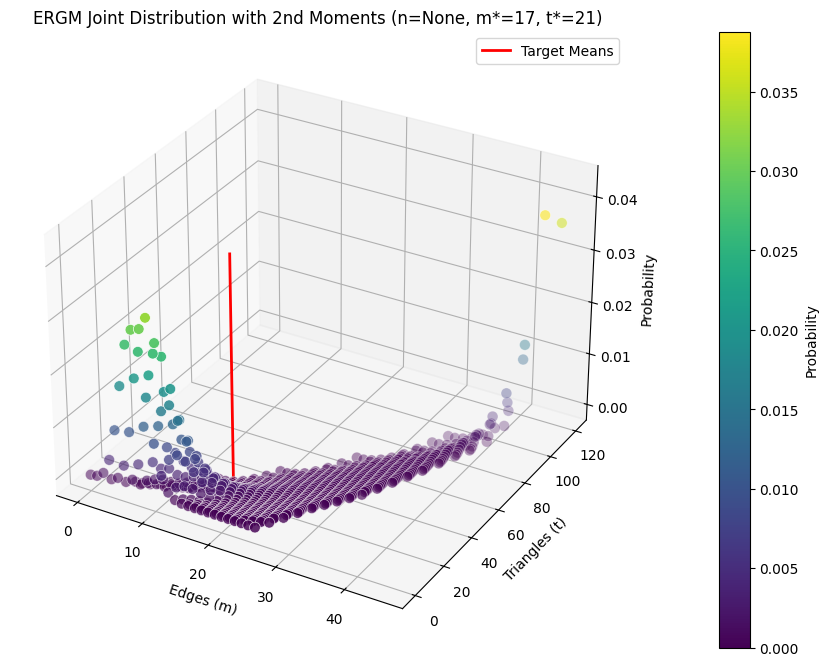

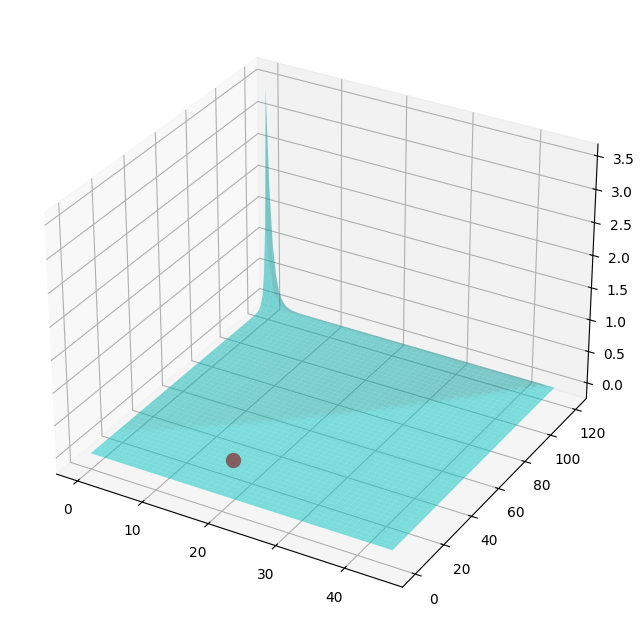

In [40]:
m_star = 17
t_star = 21
var_m_star = 150
var_t_star = 1400
n=10

try:
    roots = find_ergm_parameters_variance(n, m_star, t_star, var_m_star, var_t_star, exact_dist, delta_start=-0.01, epsilon_start=-0.01)
    print(f"Parameters found: alpha={roots[0]}, beta={roots[1]}, gamma={roots[2]}, delta={roots[3]}, epsilon={roots[4]}")
    
    # 4. Plot the distribution (assuming plot_distribution is defined)
    plot_ergm_distribution_variance(roots[0], roots[1], roots[2], roots[3], roots[4], exact_dist, m_star=m_star, t_star=t_star)
    plot_ergm_curve_variance(roots[0], roots[1], roots[2], roots[3], roots[4], exact_dist, m_star=m_star, t_star=t_star)
    
except Exception as e:
    print(f"Could not solve/plot for m={m_star}, t={t_star}: {e}")

In [1]:
import pandas as pd

n=10
df = pd.read_csv(f'joint_distribution_n{n}.csv')
df.head()

,Edges,Triangles,Count
0,0,0,1
1,1,0,45
2,2,0,990
3,3,0,14070
4,3,1,120


In [6]:

exact_dist = {}
for _, row in df.iterrows():
    m = int(row['Edges'])
    t = int(row['Triangles'])
    count = int(row['Count'])
    exact_dist[(m, t)] = count

In [17]:
import mpmath
mpmath.mp.dps = 50
def find_fact_parameters(n, m_star, t_star, exact_dist=exact_dist):
    def equations(alpha, beta, gamma):
        total_prob = 0
        expected_edges = 0
        expected_triangles = 0
        #print(f"Trying alpha={alpha}, beta={beta}, gamma={gamma}")
        for (m, t), count in sorted(exact_dist.items()):
            H = alpha + beta * m + gamma * t
            log_H = mpmath.log(H)
            log_p = -H * (log_H + mpmath.log(log_H))
            
            prob = count * mpmath.exp(log_p)
            total_prob += prob
            expected_edges += m * prob
            expected_triangles += t * prob
        return [total_prob - 1, expected_edges - m_star, expected_triangles - t_star]
    beta_start = 0.5
    gamma_start = 0.5
    alpha_start = 2
    roots = mpmath.findroot(equations, [alpha_start, beta_start, gamma_start],tol=1e-4, maxsteps = 1000)
    return roots


m_star = 17
t_star = 21
try:
    roots = find_fact_parameters(n, m_star, t_star, exact_dist)
    print(f"Parameters found: alpha={roots[0]}, beta={roots[1]}, gamma={roots[2]}")
except Exception as e:
    print(f"Could not solve for m={m_star}, t={t_star}: {e}")


Could not solve for m=17, t=21: logarithm of a negative number


In [19]:
import mpmath

# Correct syntax for global precision
mpmath.mp.dps = 50

def find_fact_parameters(n, m_star, t_star, exact_dist=exact_dist):
    def equations(alpha, beta, gamma):
        total_prob = 0
        expected_edges = 0
        expected_triangles = 0
        
        for (m, t), count in sorted(exact_dist.items()):
            H = alpha + beta * m + gamma * t
            
            # Domain Guard: Prevent H <= 1 from crashing the logarithmic evaluation.
            # Returning large penalty values pushes the solver away from this invalid region.
            if H <= 1.0:
                return [mpmath.mpf('1e50'), mpmath.mpf('1e50'), mpmath.mpf('1e50')]
            
            log_H = mpmath.log(H)
            log_p = -H * (log_H + mpmath.log(log_H))
            
            prob = count * mpmath.exp(log_p)
            total_prob += prob
            expected_edges += m * prob
            expected_triangles += t * prob
            
        return [total_prob - 1, expected_edges - m_star, expected_triangles - t_star]

    beta_start = 0.5
    gamma_start = 0.5
    alpha_start = 2
    
    roots = mpmath.findroot(equations, [alpha_start, beta_start, gamma_start], tol=1e-4, maxsteps=1000)
    return roots

m_star = 20
t_star = 25
try:
    roots = find_fact_parameters(n, m_star, t_star, exact_dist)
    print(f"Parameters found: alpha={roots[0]}, beta={roots[1]}, gamma={roots[2]}")
except Exception as e:
    print(f"Could not solve for m={m_star}, t={t_star}: {e}")

Parameters found: alpha=5.5023757748830553489377917449512934129581431081702, beta=0.31688827775430254479512083502052499300892171650579, gamma=-0.134745838677959519041999570661206680193806342441


In [25]:
import matplotlib.pyplot as plt
import mpmath

def plot_fact_distribution(alpha, beta, gamma, exact_dist=None, m_star=None, t_star=None, n=None):
    m_vals = []
    t_vals = []
    probs = []
    
    for (m, t), count in exact_dist.items():
        H = alpha + beta * m + gamma * t
        log_H = mpmath.log(H)
        log_p = -H * (log_H + mpmath.log(log_H))
            
        prob = count * mpmath.exp(log_p)
        m_vals.append(m)
        t_vals.append(t)
        probs.append(float(prob))

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    scatter = ax.scatter(m_vals, t_vals, probs, 
                        c=probs, cmap='viridis', 
                        s=60, edgecolors='w', linewidth=0.5)

    ax.set_xlabel('Edges (m)')
    ax.set_ylabel('Triangles (t)')
    ax.set_zlabel('Probability')
    plt.colorbar(scatter, label='Probability', pad=0.1)
    
    if m_star is not None and t_star is not None:
        plt.title(f'Joint Distribution (n=10, m*={m_star}, t*={t_star})')
        ax.plot([m_star]*2, [t_star]*2, [0, 1.1*max(probs)], color='red', label=f'$m^*$ and $t^*$', linewidth=2)
        plt.legend()
    
    plt.show()

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import mpmath

mpmath.dps = 50

def plot_fact_curve(alpha, beta, gamma, exact_dist=None, m_star=None, t_star=None):
    if exact_dist:
        m_vals = [m for (m, t) in exact_dist.keys()]
        t_vals = [t for (m, t) in exact_dist.keys()]
        m_min, m_max = min(m_vals), max(m_vals)
        t_min, t_max = min(t_vals), max(t_vals)
    else:
        # Default ranges if no exact_dist is provided
        m_min, m_max, t_min, t_max = 0, 40, 0, 120

    def compute_log_z(m, t):
        h_val = alpha + beta * m + gamma * t
        # Log is undefined for H <= 1 in this context
        if h_val <= 1.000001: 
            return -100.0 # Representing a very low log-probability
        
        log_h = mpmath.log(h_val)
        # We return the log_p directly instead of exp(log_p)
        log_p = -h_val * (log_h + mpmath.log(log_h))
        return float(mpmath.exp(log_p))

    v_compute_log_z = np.vectorize(compute_log_z)

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Use the specific range variables
    m_range = np.linspace(m_min, m_max, 70)
    t_range = np.linspace(t_min, t_max, 70)
    M, T = np.meshgrid(m_range, t_range)
    
    # Z now represents log(P)
    Z_log = v_compute_log_z(M, T)
    
    surf = ax.plot_surface(M, T, Z_log, cmap='plasma', alpha=0.8, antialiased=True)

    # Labeling as Log Probability
    ax.set_xlabel('M')
    ax.set_ylabel('T')
    ax.set_zlabel('log P(M, T)')
    ax.set_title('Prob-Surface Visualization')
    
    # Set limits to the requested range
    ax.set_xlim(m_min, m_max)
    ax.set_ylim(t_min, t_max)
    
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Prob Scale Value')
    plt.show()

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import mpmath

mpmath.dps = 50

def plot_fact_contour(alpha, beta, gamma, m_min=0, m_max=45, t_min=0, t_max=120):
    def compute_z(m, t):
        h_val = alpha + beta * m + gamma * t
        if h_val <= 1.1: 
            return 0.0 
        log_h = mpmath.log(h_val)
        log_p = -h_val * (log_h + mpmath.log(log_h))
        return float(log_p)

    v_compute_z = np.vectorize(compute_z)

    m_range = np.linspace(m_min, m_max, 200)
    t_range = np.linspace(t_min, t_max, 200)
    M, T = np.meshgrid(m_range, t_range)
    
    Z = v_compute_z(M, T)

    plt.figure(figsize=(10, 7))
    
    # Levels=20 provides enough lines to see the gradient near the spike
    contour = plt.contourf(M, T, Z, levels=20, cmap='viridis')
    plt.colorbar(contour, label='Log Probability P(M, T)')
    
    # Adding specific contour lines to show the H=const paths
    lines = plt.contour(M, T, Z, levels=10, colors='white', alpha=0.3)
    plt.clabel(lines, inline=True, fontsize=8)

    plt.xlabel('M')
    plt.ylabel('T')
    plt.title(f'Log Prob Contour Map')
    plt.show()

Parameters found: alpha=5.245726402001288219621496102154386607837254917737, beta=0.34114665187349014595249416197087475207110657091699, gamma=-0.1435174205159223565135648534650044651886204200786


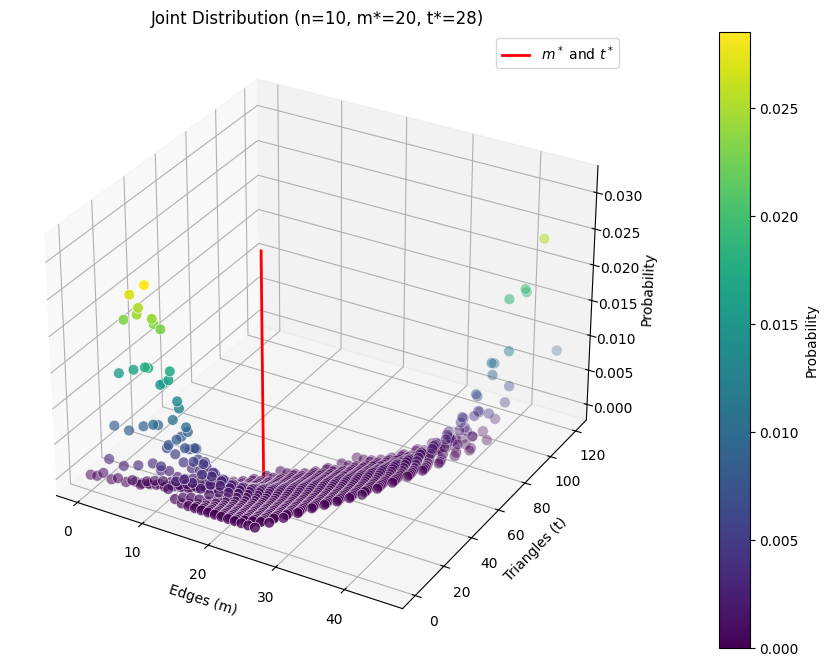

Could not solve/plot for m=20, t=28: name 'plot_fact_curve' is not defined


In [26]:
m_star = 20
t_star = 28
n=10

try:
    roots = find_fact_parameters(n, m_star, t_star, exact_dist)
    print(f"Parameters found: alpha={roots[0]}, beta={roots[1]}, gamma={roots[2]}")
 
    plot_fact_distribution(roots[0], roots[1], roots[2],
                            exact_dist, m_star=m_star, t_star=t_star)
    plot_fact_curve(roots[0], roots[1], roots[2], exact_dist, m_star=m_star, t_star=t_star)
    plot_fact_contour(roots[0], roots[1], roots[2])
    
except Exception as e:
    print(f"Could not solve/plot for m={m_star}, t={t_star}: {e}")